#### CELL 1 — Imports

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

#### CELL 2 — File paths and user knobs

In [7]:
# -------------------- FILE PATHS --------------------
BASE_DIR = Path(r"C:\Users\owner\NADA Project\w400\s161_1\Raw")

FP_EVENTS = Path(r"C:\Users\owner\NADA Project\w400\s161_1\Raw\First_Appear_Run\First_appearance_events_s161_1.csv")
FP_CELLS  = Path(r"C:\Users\owner\NADA Project\w400\s161_1\Raw\Cellpose_Out\csv\cellpose_cells_by_frame.csv")
FP_COUNTS = Path(r"C:\Users\owner\NADA Project\w400\s161_1\Raw\Cellpose_Out\csv\cell_counts_per_frame.csv")
FP_VRAW   = Path(r"C:\Users\owner\NADA Project\w400\s161_1\Raw\optical_flow_velocity_profiles\velocity_profiles_X_raw_long_0000_0100.csv")

# -------------------- CORE PHYSICAL SETTINGS --------------------
UM_PER_PX = 0.74
MM_PER_PX = UM_PER_PX / 1000.0
DT_H = 0.25                  # 15 min = 0.25 h

# Use None to infer from the velocity table
X_CENTER_PX = None

# Image/ROI height for areal density
# If None, estimate from centroid_y max.
# A small error here rescales rho, LHS, and RHS together, so closure slope is unaffected.
IMAGE_H_PX = None

# -------------------- ANALYSIS GRID --------------------
DX_PX = 25                   # binning for x dimension; 25 px = 18.5 um
# DX_MM = DX_PX * MM_PER_PX
PROLIF_WINDOW_PAIRS = 5      # 5 pairs = 1.25 h

# -------------------- SMOOTHING BEFORE DERIVATIVES --------------------
# Gentle stabilizers for derivative terms.
SMOOTH_RHO_T = 3
SMOOTH_RHO_X = 3

SMOOTH_VX_T = 3
SMOOTH_VX_X = 3

SMOOTH_K_T = 1
SMOOTH_K_X = 3

# -------------------- LOSS TERM --------------------
# Version 1: use zero measured loss, then infer effective loss from the residual
USE_ZERO_KLOSS = True

# -------------------- NUMERICAL SAFETY --------------------
EPS = 1e-12
RHO_FLOOR = 1e-12

# -------------------- PLOTTING --------------------
SELECTED_PAIR_IDXS = [10, 30, 50, 70, 90]
CMAP_MAIN = "viridis"
CMAP_SIGNED = "coolwarm"
SAVE_FIGS = True
FIG_DPI = 300
FIG_DIR = BASE_DIR / "mass_balance_plots"
FIG_DIR.mkdir(parents=True, exist_ok=True)

#### CELL 3 — Helper functions

In [8]:
def smooth_xt(arr, size_t=1, size_x=1):
    """Uniform smoothing along time and x. Leaves array unchanged if size=1."""
    out = np.asarray(arr, dtype=float).copy()
    if size_t > 1:
        out = uniform_filter1d(out, size=size_t, axis=0, mode="nearest")
    if size_x > 1:
        out = uniform_filter1d(out, size=size_x, axis=1, mode="nearest")
    return out

def rolling_sum_centered_2d(arr, win):
    """Centered rolling sum along time axis using zero padding."""
    arr = np.asarray(arr, dtype=float)
    if win <= 1:
        return arr.copy()
    kernel = np.ones(int(win), dtype=float)
    out = np.empty_like(arr, dtype=float)
    for j in range(arr.shape[1]):
        out[:, j] = np.convolve(arr[:, j], kernel, mode="same")
    return out

def make_x_edges_px(width_px, dx_px):
    edges = np.arange(0, width_px + dx_px, dx_px, dtype=float)
    if edges[-1] < width_px:
        edges = np.r_[edges, width_px]
    elif edges[-1] > width_px:
        edges[-1] = width_px
    return edges

def centers_from_edges(edges):
    edges = np.asarray(edges, dtype=float)
    return 0.5 * (edges[:-1] + edges[1:])

def bin_counts_by_frame(df, frame_col, x_col_px, frame_values, x_edges_px):
    out = np.zeros((len(frame_values), len(x_edges_px) - 1), dtype=float)
    frame_to_idx = {int(f): i for i, f in enumerate(frame_values)}

    for fr, grp in df.groupby(frame_col):
        fr = int(fr)
        if fr not in frame_to_idx:
            continue
        hist, _ = np.histogram(grp[x_col_px].values, bins=x_edges_px)
        out[frame_to_idx[fr], :] = hist

    return out

def build_velocity_xt(vraw, pair0_values, x_edges_px, vel_col="vx"):
    out = np.full((len(pair0_values), len(x_edges_px) - 1), np.nan, dtype=float)
    pair_to_idx = {int(f): i for i, f in enumerate(pair0_values)}

    for fr, grp in vraw.groupby("frame0"):
        fr = int(fr)
        if fr not in pair_to_idx:
            continue

        xvals = grp["x_px"].values
        vvals = grp[vel_col].values
        bin_idx = np.digitize(xvals, x_edges_px) - 1

        row = np.full(len(x_edges_px) - 1, np.nan, dtype=float)
        for bi in range(len(row)):
            m = vvals[bin_idx == bi]
            if m.size > 0:
                row[bi] = np.nanmean(m)

        out[pair_to_idx[fr], :] = row

    return out

def diff_x_centered(arr, dx):
    """Spatial derivative along x with centered differences and one-sided edges."""
    arr = np.asarray(arr, dtype=float)
    out = np.full_like(arr, np.nan, dtype=float)

    out[:, 1:-1] = (arr[:, 2:] - arr[:, :-2]) / (2.0 * dx)
    out[:, 0] = (arr[:, 1] - arr[:, 0]) / dx
    out[:, -1] = (arr[:, -1] - arr[:, -2]) / dx
    return out

def robust_limits(data, pct=99):
    data = np.asarray(data, dtype=float)
    vals = data[np.isfinite(data)]
    if vals.size == 0:
        return None, None
    lo = np.percentile(vals, 100 - pct)
    hi = np.percentile(vals, pct)
    return lo, hi

def robust_signed_limits(data, pct=99):
    data = np.asarray(data, dtype=float)
    vals = data[np.isfinite(data)]
    if vals.size == 0:
        return None, None
    m = np.percentile(np.abs(vals), pct)
    return -m, m

# def plot_xt_map(ax, data, x_centers_um, t_vals, title, cbar_label, cmap="viridis", signed=False):
def plot_xt_map(ax, data, x_centers_mm, t_vals, title, cbar_label, cmap="viridis", signed=False):
    if signed:
        vmin, vmax = robust_signed_limits(data, pct=99)
    else:
        vmin, vmax = robust_limits(data, pct=99)

    im = ax.imshow(
        data,
        aspect="auto",
        origin="lower",
        # extent=[x_centers_um[0], x_centers_um[-1], t_vals[0], t_vals[-1]],
        extent=[x_centers_mm[0], x_centers_mm[-1], t_vals[0], t_vals[-1]],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    # ax.set_xlabel("X (µm, centered)")
    ax.set_xlabel("X (mm, centered)")
    ax.set_ylabel("Time (h)")
    ax.set_title(title)
    cb = plt.colorbar(im, ax=ax, pad=0.02)
    cb.set_label(cbar_label)
    return im

def safe_polyfit(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan, np.nan
    slope, intercept = np.polyfit(x[m], y[m], 1)
    return slope, intercept

#### CELL 4 — Load the actual uploaded CSVs and prepare coordinates

In [9]:
# -------------------- LOAD --------------------
df_events = pd.read_csv(FP_EVENTS)
df_cells  = pd.read_csv(FP_CELLS)
df_counts = pd.read_csv(FP_COUNTS)
df_vraw   = pd.read_csv(FP_VRAW)

# -------------------- BASIC CHECKS --------------------
print("events:", df_events.shape, df_events.columns.tolist())
print("cells :", df_cells.shape, df_cells.columns.tolist())
print("counts:", df_counts.shape, df_counts.columns.tolist())
print("vraw  :", df_vraw.shape, df_vraw.columns.tolist())

# -------------------- FRAME AXES --------------------
frames = np.arange(int(df_counts["frame"].min()), int(df_counts["frame"].max()) + 1, dtype=int)   # 0..100
pair0s = np.sort(df_vraw["frame0"].unique().astype(int))                                           # 0..99

assert np.array_equal(frames, np.arange(0, 101))
assert np.array_equal(pair0s, np.arange(0, 100))

frame_times_h = frames * DT_H
pair_times_h = pair0s * DT_H + 0.5 * DT_H

# -------------------- X CENTER --------------------
if X_CENTER_PX is None:
    # infer from raw velocity table
    x_min_px = float(df_vraw["x_px"].min())
    x_max_px = float(df_vraw["x_px"].max())
    X_CENTER_PX = 0.5 * (x_min_px + x_max_px)

# -------------------- IMAGE GEOMETRY --------------------
IMAGE_W_PX = int(np.floor(df_vraw["x_px"].max())) + 1

if IMAGE_H_PX is None:
    IMAGE_H_PX = int(np.ceil(df_cells["centroid_y"].max())) + 1

print("X_CENTER_PX =", X_CENTER_PX)
print("IMAGE_W_PX  =", IMAGE_W_PX)
print("IMAGE_H_PX  =", IMAGE_H_PX)

# -------------------- ADD RAW + CENTERED X FOR CELLS / EVENTS --------------------
df_cells["x_px"] = df_cells["centroid_x"].astype(float)
df_cells["x_px_centered"] = df_cells["x_px"] - float(X_CENTER_PX)
# df_cells["x_um"] = df_cells["x_px"] * UM_PER_PX
# df_cells["x_um_centered"] = df_cells["x_px_centered"] * UM_PER_PX
df_cells["x_mm"] = df_cells["x_px"] * MM_PER_PX
df_cells["x_mm_centered"] = df_cells["x_px_centered"] * MM_PER_PX


df_events["x_px"] = df_events["first_x"].astype(float)
df_events["x_px_centered"] = df_events["x_px"] - float(X_CENTER_PX)
# df_events["x_um"] = df_events["x_px"] * UM_PER_PX
# df_events["x_um_centered"] = df_events["x_px_centered"] * UM_PER_PX
df_events["x_mm"] = df_events["x_px"] * MM_PER_PX
df_events["x_mm_centered"] = df_events["x_px_centered"] * MM_PER_PX


# -------------------- COMMON X BINS --------------------
x_edges_px = make_x_edges_px(width_px=IMAGE_W_PX, dx_px=DX_PX)
x_centers_px = centers_from_edges(x_edges_px)
x_centers_px_centered = x_centers_px - float(X_CENTER_PX)
# x_centers_um_centered = x_centers_px_centered * UM_PER_PX
x_centers_mm_centered = x_centers_px_centered * MM_PER_PX


bin_widths_px = np.diff(x_edges_px)
# bin_widths_um = bin_widths_px * UM_PER_PX
# image_h_um = IMAGE_H_PX * UM_PER_PX
# bin_areas_um2 = bin_widths_um * image_h_um

bin_widths_mm = bin_widths_px * MM_PER_PX
image_h_mm = IMAGE_H_PX * MM_PER_PX
bin_areas_mm2 = bin_widths_mm * image_h_mm

dx_mm_nominal = DX_PX * MM_PER_PX
print("n_x_bins =", len(x_centers_mm_centered))
print("x range centered (mm):", x_centers_mm_centered[0], "to", x_centers_mm_centered[-1])
print("dx_mm_nominal =", dx_mm_nominal)

events: (1631, 13) ['track_id', 'first_frame', 'confirm_frame', 'first_y', 'first_x', 'first_area', 'first_perimeter', 'first_circularity', 'confirm_area', 'confirm_perimeter', 'confirm_circularity', 'path_first', 'path_confirm']
cells : (118481, 7) ['frame', 'cell_id', 'area_px', 'centroid_x', 'centroid_y', 'mask_file', 'image_file']
counts: (101, 4) ['frame', 'n_cells', 'mask_file', 'image_file']
vraw  : (55500, 10) ['frame0', 'frame1', 't_mid_frame', 't_mid_hr', 'x_px', 'x_px_centered', 'x_um', 'x_um_centered', 'vx', 'vy']
X_CENTER_PX = 277.0
IMAGE_W_PX  = 555
IMAGE_H_PX  = 2026
n_x_bins = 23
x range centered (mm): -0.19573 to 0.20387
dx_mm_nominal = 0.0185


#### CELL 5 — Build total counts, density map, velocity map, and proliferation map

In [6]:
# -------------------- TOTAL CELL COUNT VS TIME --------------------
# use df_counts directly for the raw total-cell-count plot
total_count_t = df_counts.sort_values("frame")["n_cells"].values.astype(float)

# -------------------- COUNTS PER X-BIN PER FRAME --------------------
counts_xt = bin_counts_by_frame(
    df=df_cells,
    frame_col="frame",
    x_col_px="x_px",
    frame_values=frames,
    x_edges_px=x_edges_px
)  # shape = (101, n_bins)

# -------------------- DENSITY rho(x,t) --------------------
# rho_xt = counts_xt / np.maximum(bin_areas_um2[None, :], EPS)   # cells / µm^2
rho_xt = counts_xt / np.maximum(bin_areas_mm2[None, :], EPS)   # cells / mm^2

# midpoint density for pair-based terms
rho_mid_xt = 0.5 * (rho_xt[:-1, :] + rho_xt[1:, :])            # shape = (100, n_bins)

# -------------------- VELOCITY vx(x,t) FROM RAW LONG TABLE --------------------
# vx_xt = build_velocity_xt(df_vraw, pair0_values=pair0s, x_edges_px=x_edges_px, vel_col="vx")
# vy_xt = build_velocity_xt(df_vraw, pair0_values=pair0s, x_edges_px=x_edges_px, vel_col="vy")
vx_xt = build_velocity_xt(df_vraw, pair0_values=pair0s, x_edges_px=x_edges_px, vel_col="vx")
vy_xt = build_velocity_xt(df_vraw, pair0_values=pair0s, x_edges_px=x_edges_px, vel_col="vy")

# raw optical-flow velocities are in µm/h -> convert to mm/h
vx_xt = vx_xt / 1000.0
vy_xt = vy_xt / 1000.0

# -------------------- EVENT COUNTS PER FRAME0 / X-BIN --------------------
# events are keyed by first_frame, which runs 0..99 in your file
event_counts_xt = bin_counts_by_frame(
    df=df_events,
    frame_col="first_frame",
    x_col_px="x_px",
    frame_values=pair0s,
    x_edges_px=x_edges_px
)  # shape = (100, n_bins)

# -------------------- CONVERT EVENTS -> PER-CAPITA k_prolif(x,t) --------------------
# numerator: rolling sum of events across time window
events_win_xt = rolling_sum_centered_2d(event_counts_xt, PROLIF_WINDOW_PAIRS)

# denominator: rolling sum of local cell-hours across same time window
# local cell count at pair midpoints:
count_mid_xt = 0.5 * (counts_xt[:-1, :] + counts_xt[1:, :])            # cells / bin
cell_hours_xt = count_mid_xt * DT_H                                     # cell-hours / pair / bin
cell_hours_win_xt = rolling_sum_centered_2d(cell_hours_xt, PROLIF_WINDOW_PAIRS)

# per-capita proliferation rate
kprolif_xt = events_win_xt / np.maximum(cell_hours_win_xt, EPS)         # 1 / h

# -------------------- QUICK QC --------------------
print("counts_xt shape :", counts_xt.shape)
print("rho_xt shape    :", rho_xt.shape)
print("rho_mid_xt shape:", rho_mid_xt.shape)
print("vx_xt shape     :", vx_xt.shape)
print("kprolif_xt shape:", kprolif_xt.shape)
print("Total events    :", int(df_events.shape[0]))

counts_xt shape : (101, 23)
rho_xt shape    : (101, 23)
rho_mid_xt shape: (100, 23)
vx_xt shape     : (100, 23)
kprolif_xt shape: (100, 23)
Total events    : 1631


#### CELL 6 — Smooth fields, compute derivatives, LHS, RHS, residual, and effective loss

In [7]:
# -------------------- SMOOTH FIELDS BEFORE DERIVATIVES --------------------
rho_xt_use = smooth_xt(rho_xt, size_t=SMOOTH_RHO_T, size_x=SMOOTH_RHO_X)
rho_mid_use = 0.5 * (rho_xt_use[:-1, :] + rho_xt_use[1:, :])

vx_use = smooth_xt(vx_xt, size_t=SMOOTH_VX_T, size_x=SMOOTH_VX_X)
kprolif_use = smooth_xt(kprolif_xt, size_t=SMOOTH_K_T, size_x=SMOOTH_K_X)

# -------------------- TIME DERIVATIVE: ∂t rho --------------------
drho_dt_xt = (rho_xt_use[1:, :] - rho_xt_use[:-1, :]) / DT_H

# -------------------- FLUX AND SPATIAL DERIVATIVE --------------------
flux_xt = rho_mid_use * vx_use
# dflux_dx_xt = diff_x_centered(flux_xt, dx=dx_um_nominal)
dflux_dx_xt = diff_x_centered(flux_xt, dx=dx_mm_nominal)

# -------------------- LOSS TERM --------------------
if USE_ZERO_KLOSS:
    kloss_xt = np.zeros_like(kprolif_use)
else:
    raise NotImplementedError("This notebook version uses k_loss = 0 first, then infers k_loss_eff from the residual.")

# -------------------- BALANCE TERMS --------------------
lhs_xt = drho_dt_xt + dflux_dx_xt
rhs_xt = (kprolif_use - kloss_xt) * rho_mid_use
residual_xt = lhs_xt - rhs_xt

# inferred effective loss from the residual
kloss_eff_xt = np.where(
    rho_mid_use > RHO_FLOOR,
    -residual_xt / np.maximum(rho_mid_use, EPS),
    np.nan
)

# -------------------- CLOSURE METRICS --------------------
mask = np.isfinite(lhs_xt) & np.isfinite(rhs_xt)

lhs_vals = lhs_xt[mask]
rhs_vals = rhs_xt[mask]

corr = np.corrcoef(rhs_vals, lhs_vals)[0, 1] if lhs_vals.size > 2 else np.nan
slope, intercept = safe_polyfit(rhs_vals, lhs_vals)
rmse = np.sqrt(np.nanmean((lhs_vals - rhs_vals) ** 2)) if lhs_vals.size else np.nan
lhs_mean = np.nanmean(lhs_vals) if lhs_vals.size else np.nan
rhs_mean = np.nanmean(rhs_vals) if rhs_vals.size else np.nan
res_mean = np.nanmean(residual_xt)

print("----- MASS BALANCE SUMMARY -----")
# print(f"LHS mean       = {lhs_mean:.6e} cells/(µm²·h)")
# print(f"RHS mean       = {rhs_mean:.6e} cells/(µm²·h)")
# print(f"Residual mean  = {res_mean:.6e} cells/(µm²·h)")
print(f"LHS mean       = {lhs_mean:.6e} cells/(mm²·h)")
print(f"RHS mean       = {rhs_mean:.6e} cells/(mm²·h)")
print(f"Residual mean  = {res_mean:.6e} cells/(mm²·h)")
print(f"corr(LHS,RHS)  = {corr:.4f}")
print(f"slope          = {slope:.4f}")
print(f"intercept      = {intercept:.6e}")
print(f"RMSE           = {rmse:.6e}")

# simple edge-vs-center effective-loss summary
# edge_mask = np.abs(x_centers_um_centered) > 100
# center_mask = np.abs(x_centers_um_centered) < 50
edge_mask = np.abs(x_centers_mm_centered) > 0.100
center_mask = np.abs(x_centers_mm_centered) < 0.050

edge_mean = np.nanmean(kloss_eff_xt[:, edge_mask])
center_mean = np.nanmean(kloss_eff_xt[:, center_mask])

print(f"mean k_loss_eff at edges  = {edge_mean:.4e} 1/h")
print(f"mean k_loss_eff at center = {center_mean:.4e} 1/h")

----- MASS BALANCE SUMMARY -----
LHS mean       = 1.232816e+01 cells/(mm²·h)
RHS mean       = 1.027077e+02 cells/(mm²·h)
Residual mean  = -9.037950e+01 cells/(mm²·h)
corr(LHS,RHS)  = -0.0214
slope          = -0.1294
intercept      = 2.561401e+01
RMSE           = 2.670811e+02
mean k_loss_eff at edges  = 5.6884e-02 1/h
mean k_loss_eff at center = 2.5178e-02 1/h


#### CELL 7 — Plot 1: total cell count vs time

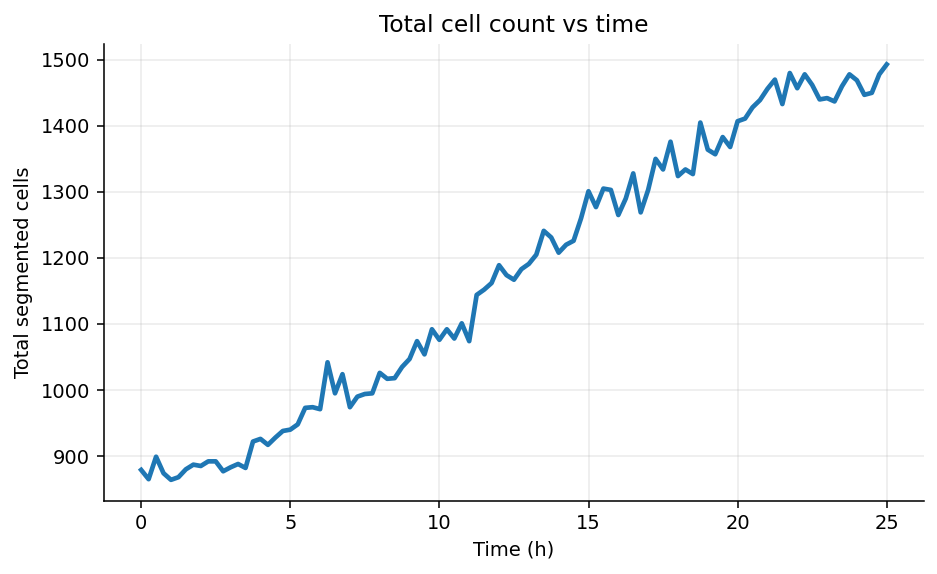

In [8]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(frame_times_h, total_count_t, lw=2.4)
ax.set_xlabel("Time (h)")
ax.set_ylabel("Total segmented cells")
ax.set_title("Total cell count vs time")
ax.grid(alpha=0.25)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(FIG_DIR / "01_total_cell_count_vs_time.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

#### CELL 8 — Plots 2 to 8: heatmaps

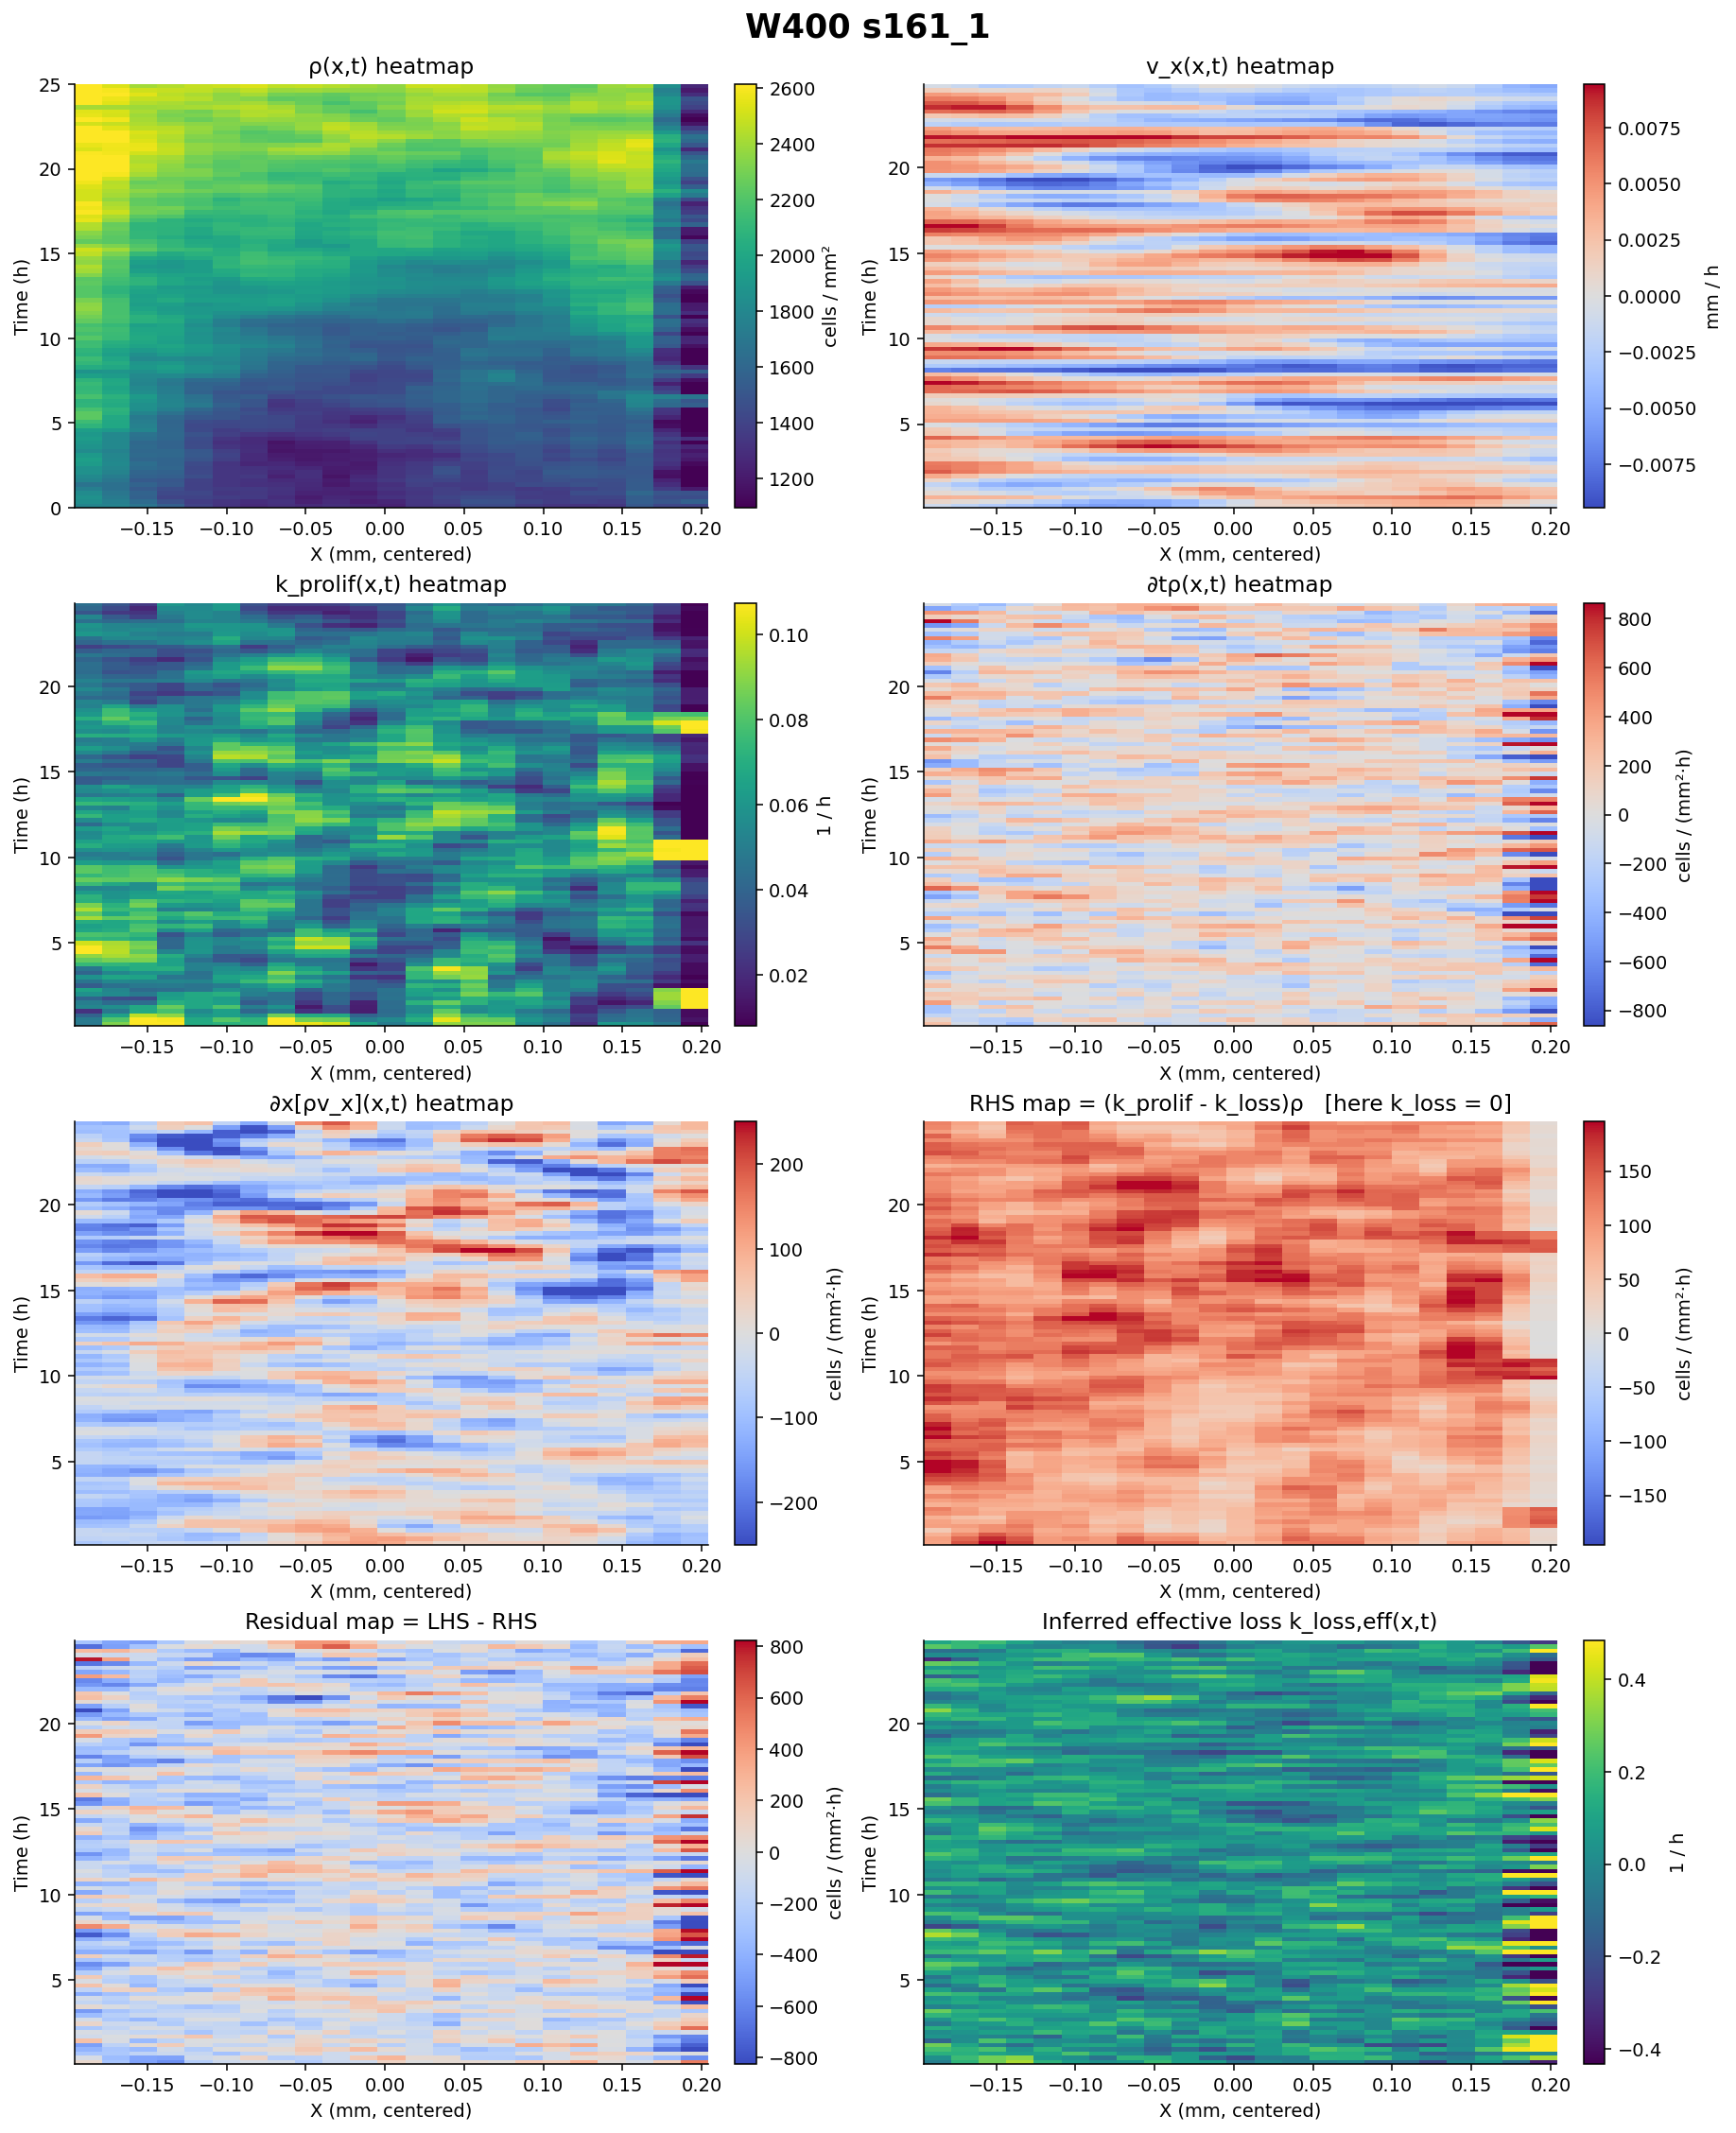

In [9]:
fig, axs = plt.subplots(4, 2, figsize=(13, 16), constrained_layout=True)
fig.suptitle(f"{Path(BASE_DIR).parent.parent.name.upper()} {Path(BASE_DIR).parent.name}", fontsize=18, fontweight="bold")      # dataset title from folder name

plot_xt_map(
    axs[0, 0], rho_xt_use, x_centers_mm_centered, frame_times_h,
    title="ρ(x,t) heatmap",
    cbar_label="cells / mm²",
    cmap=CMAP_MAIN,
    signed=False
)

plot_xt_map(
    axs[0, 1], vx_use, x_centers_mm_centered, pair_times_h,
    title="v_x(x,t) heatmap",
    cbar_label="mm / h",
    cmap=CMAP_SIGNED,
    signed=True
)

plot_xt_map(
    axs[1, 0], kprolif_use, x_centers_mm_centered, pair_times_h,
    title="k_prolif(x,t) heatmap",
    cbar_label="1 / h",
    cmap=CMAP_MAIN,
    signed=False
)

plot_xt_map(
    axs[1, 1], drho_dt_xt, x_centers_mm_centered, pair_times_h,
    title="∂tρ(x,t) heatmap",
    cbar_label="cells / (mm²·h)",
    cmap=CMAP_SIGNED,
    signed=True
)

plot_xt_map(
    axs[2, 0], dflux_dx_xt, x_centers_mm_centered, pair_times_h,
    title="∂x[ρv_x](x,t) heatmap",
    cbar_label="cells / (mm²·h)",
    cmap=CMAP_SIGNED,
    signed=True
)

plot_xt_map(
    axs[2, 1], rhs_xt, x_centers_mm_centered, pair_times_h,
    title="RHS map = (k_prolif - k_loss)ρ   [here k_loss = 0]",
    cbar_label="cells / (mm²·h)",
    cmap=CMAP_SIGNED,
    signed=True
)

plot_xt_map(
    axs[3, 0], residual_xt, x_centers_mm_centered, pair_times_h,
    title="Residual map = LHS - RHS",
    cbar_label="cells / (mm²·h)",
    cmap=CMAP_SIGNED,
    signed=True
)

plot_xt_map(
    axs[3, 1], kloss_eff_xt, x_centers_mm_centered, pair_times_h,
    title="Inferred effective loss k_loss,eff(x,t)",
    cbar_label="1 / h",
    cmap=CMAP_MAIN,
    signed=False
)

if SAVE_FIGS:
    fig.savefig(FIG_DIR / "02_08_heatmaps_panel.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

#### CELL 9 — Plot 9: LHS vs RHS scatter

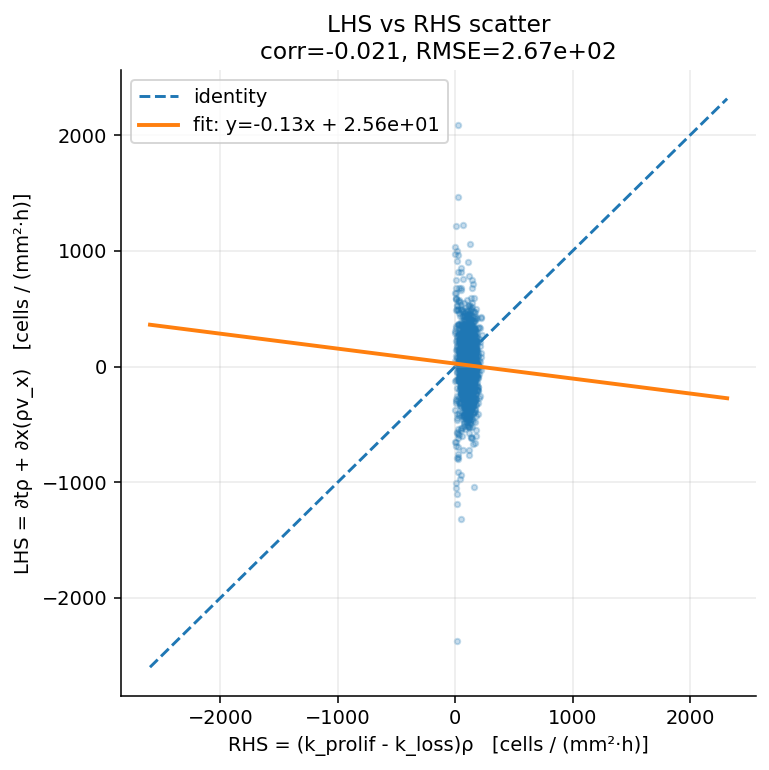

In [10]:
fig, ax = plt.subplots(figsize=(5.6, 5.6))

ax.scatter(rhs_vals, lhs_vals, s=8, alpha=0.25)
mn = np.nanmin([lhs_vals.min(), rhs_vals.min()])
mx = np.nanmax([lhs_vals.max(), rhs_vals.max()])
pad = 0.05 * (mx - mn)

ax.plot([mn - pad, mx + pad], [mn - pad, mx + pad], "--", lw=1.5, label="identity")
if np.isfinite(slope):
    xx = np.linspace(mn - pad, mx + pad, 200)
    ax.plot(xx, slope * xx + intercept, lw=2.0, label=f"fit: y={slope:.2f}x + {intercept:.2e}")

ax.set_xlabel("RHS = (k_prolif - k_loss)ρ   [cells / (mm²·h)]")
ax.set_ylabel("LHS = ∂tρ + ∂x(ρv_x)   [cells / (mm²·h)]")
ax.set_title(f"LHS vs RHS scatter\ncorr={corr:.3f}, RMSE={rmse:.2e}")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(FIG_DIR / "LHS vs RHS scatter.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

#### CELL 10 — Plot 10: selected-time line profiles

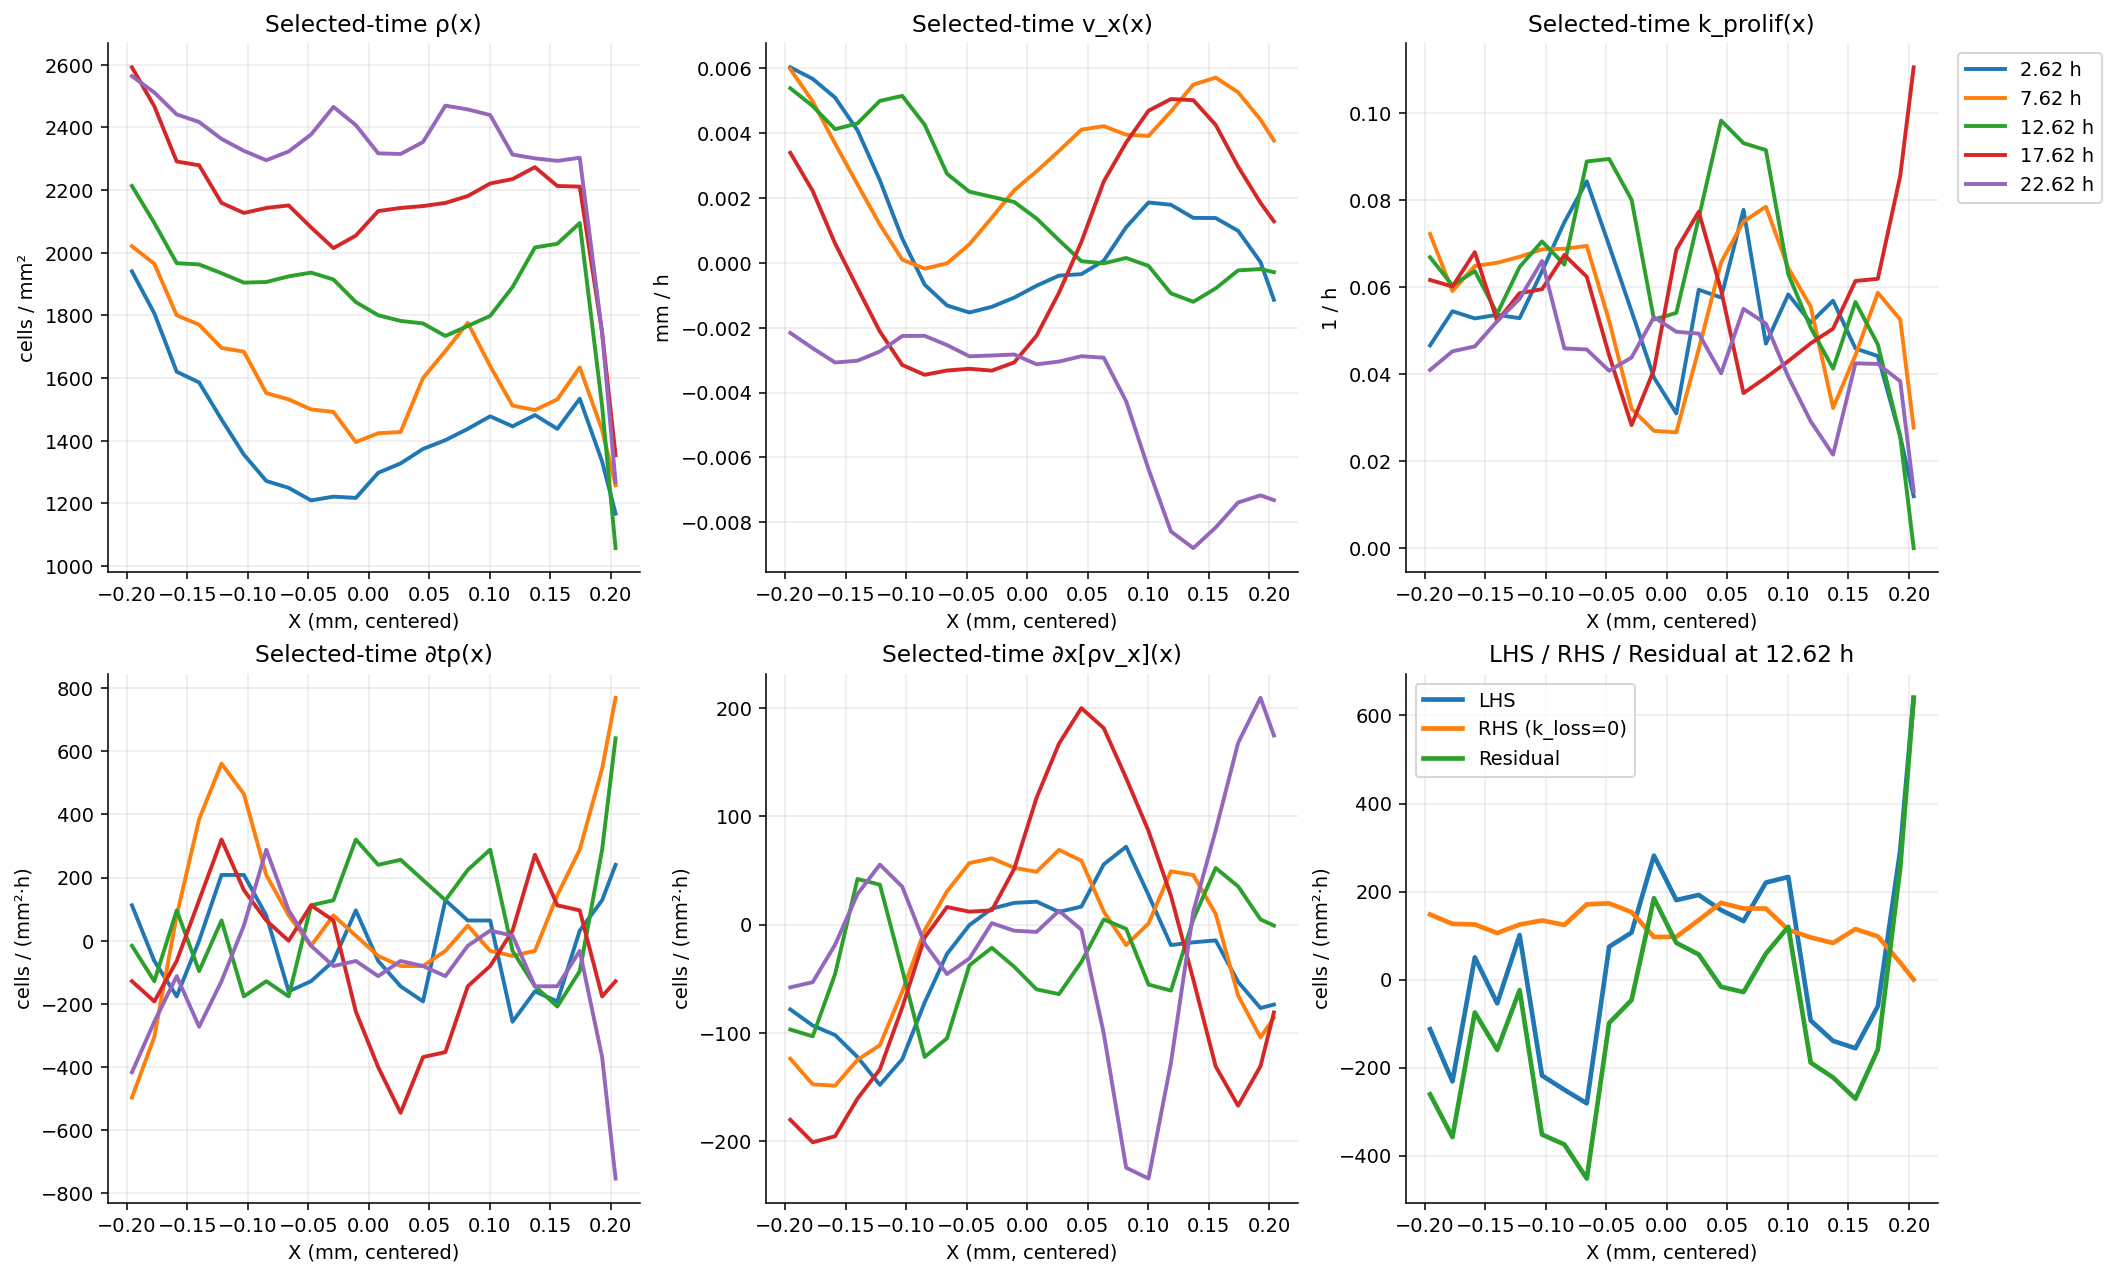

In [11]:
selected = [i for i in SELECTED_PAIR_IDXS if 0 <= i < len(pair_times_h)]
labels = [f"{pair_times_h[i]:.2f} h" for i in selected]

fig, axs = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

# rho
for i, lab in zip(selected, labels):
    axs[0, 0].plot(x_centers_mm_centered, rho_mid_use[i], lw=2, label=lab)
axs[0, 0].set_title("Selected-time ρ(x)")
axs[0, 0].set_xlabel("X (mm, centered)")
axs[0, 0].set_ylabel("cells / mm²")
axs[0, 0].grid(alpha=0.25)

# vx
for i, lab in zip(selected, labels):
    axs[0, 1].plot(x_centers_mm_centered, vx_use[i], lw=2, label=lab)
axs[0, 1].set_title("Selected-time v_x(x)")
axs[0, 1].set_xlabel("X (mm, centered)")
axs[0, 1].set_ylabel("mm / h")
axs[0, 1].grid(alpha=0.25)

# kprolif
for i, lab in zip(selected, labels):
    axs[0, 2].plot(x_centers_mm_centered, kprolif_use[i], lw=2, label=lab)
axs[0, 2].set_title("Selected-time k_prolif(x)")
axs[0, 2].set_xlabel("X (mm, centered)")
axs[0, 2].set_ylabel("1 / h")
axs[0, 2].grid(alpha=0.25)

# d(rho)/dt
for i, lab in zip(selected, labels):
    axs[1, 0].plot(x_centers_mm_centered, drho_dt_xt[i], lw=2, label=lab)
axs[1, 0].set_title("Selected-time ∂tρ(x)")
axs[1, 0].set_xlabel("X (mm, centered)")
axs[1, 0].set_ylabel("cells / (mm²·h)")
axs[1, 0].grid(alpha=0.25)

# d(ρvx)/dx
for i, lab in zip(selected, labels):
    axs[1, 1].plot(x_centers_mm_centered, dflux_dx_xt[i], lw=2, label=lab)
axs[1, 1].set_title("Selected-time ∂x[ρv_x](x)")
axs[1, 1].set_xlabel("X (mm, centered)")
axs[1, 1].set_ylabel("cells / (mm²·h)")
axs[1, 1].grid(alpha=0.25)

# LHS / RHS / residual for one representative time
rep = selected[len(selected) // 2]
axs[1, 2].plot(x_centers_mm_centered, lhs_xt[rep], lw=2.4, label="LHS")
axs[1, 2].plot(x_centers_mm_centered, rhs_xt[rep], lw=2.4, label="RHS (k_loss=0)")
axs[1, 2].plot(x_centers_mm_centered, residual_xt[rep], lw=2.4, label="Residual")
axs[1, 2].set_title(f"LHS / RHS / Residual at {pair_times_h[rep]:.2f} h")
axs[1, 2].set_xlabel("X (mm, centered)")
axs[1, 2].set_ylabel("cells / (mm²·h)")
axs[1, 2].grid(alpha=0.25)
axs[1, 2].legend()

axs[0, 2].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
if SAVE_FIGS:
    fig.savefig(FIG_DIR / "Selected_timelines_panel.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

#### CELL 11 — Plot 11: inferred effective loss profile averaged over time

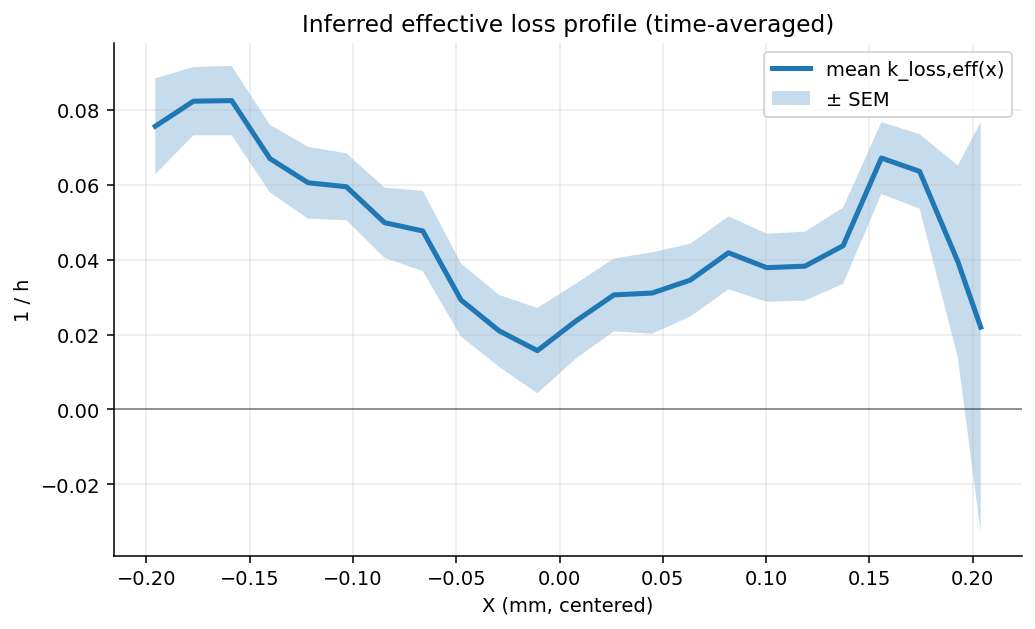

In [12]:
valid = np.isfinite(kloss_eff_xt)
n_valid = np.sum(valid, axis=0)

kloss_eff_mean_x = np.nanmean(kloss_eff_xt, axis=0)
kloss_eff_std_x = np.nanstd(kloss_eff_xt, axis=0)
kloss_eff_sem_x = kloss_eff_std_x / np.sqrt(np.maximum(n_valid, 1))

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(x_centers_mm_centered, kloss_eff_mean_x, lw=2.6, label="mean k_loss,eff(x)")
ax.fill_between(
    x_centers_mm_centered,
    kloss_eff_mean_x - kloss_eff_sem_x,
    kloss_eff_mean_x + kloss_eff_sem_x,
    alpha=0.25,
    label="± SEM"
)
ax.axhline(0, color="black", lw=1.0, alpha=0.4)
ax.set_xlabel("X (mm, centered)")
ax.set_ylabel("1 / h")
ax.set_title("Inferred effective loss profile (time-averaged)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(FIG_DIR / "Inferred effective loss profile.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

#### CELL 12 — save the computed fields as CSVs

In [13]:
OUT_DIR = BASE_DIR / "mass_balance_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# save x axis info for reference
pd.DataFrame({
    "x_center_mm": x_centers_mm_centered,
    "x_center_px_centered": x_centers_px_centered,
    "bin_area_mm2": bin_areas_mm2
}).to_csv(OUT_DIR / "x_bins.csv", index=False)

# save time axes
pd.DataFrame({"frame": frames, "t_h": frame_times_h}).to_csv(OUT_DIR / "frame_times.csv", index=False)
pd.DataFrame({"frame0": pair0s, "t_mid_h": pair_times_h}).to_csv(OUT_DIR / "pair_times.csv", index=False)

# save 2D fields in wide format
def save_wide(mat, row_ids, x_centers_mm, path, row_name="row"):
    cols = [f"{x:.3f}" for x in x_centers_mm]
    df = pd.DataFrame(mat, columns=cols)
    df.insert(0, row_name, row_ids)
    df.to_csv(path, index=False)

save_wide(rho_xt_use, frames, x_centers_mm_centered, OUT_DIR / "rho_xt.csv", row_name="frame")
save_wide(vx_use, pair0s, x_centers_mm_centered, OUT_DIR / "vx_xt.csv", row_name="frame0")
save_wide(kprolif_use, pair0s, x_centers_mm_centered, OUT_DIR / "kprolif_xt.csv", row_name="frame0")
save_wide(drho_dt_xt, pair0s, x_centers_mm_centered, OUT_DIR / "drho_dt_xt.csv", row_name="frame0")
save_wide(dflux_dx_xt, pair0s, x_centers_mm_centered, OUT_DIR / "dflux_dx_xt.csv", row_name="frame0")
save_wide(rhs_xt, pair0s, x_centers_mm_centered, OUT_DIR / "rhs_xt.csv", row_name="frame0")
save_wide(residual_xt, pair0s, x_centers_mm_centered, OUT_DIR / "residual_xt.csv", row_name="frame0")
save_wide(kloss_eff_xt, pair0s, x_centers_mm_centered, OUT_DIR / "kloss_eff_xt.csv", row_name="frame0")

print("[SAVED] outputs to", OUT_DIR)

[SAVED] outputs to C:\Users\owner\NADA Project\w400\s161_1\Raw\mass_balance_outputs


#### Cell 13- Mass Balance Variable Summary Report

In [14]:
# -------------------- MASS BALANCE SUMMARY REPORT --------------------
# This cell prints a readable summary of the main variables used in:
#
# dtρ + dx(ρv_x) = (k_prolif - k_loss)ρ
#
# and saves the summary as a .txt file.

MB_DIR = BASE_DIR / "mass_balance_equation"
MB_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_TXT = MB_DIR / "mass_balance_summary.txt"

PAIR_TO_SUMMARIZE = 50   # choose any valid pair index, e.g. 10, 30, 50, 70, 90

def _stats(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
            "median": np.nan,
        }
    return {
        "n": arr.size,
        "mean": float(np.nanmean(arr)),
        "std": float(np.nanstd(arr)),
        "min": float(np.nanmin(arr)),
        "max": float(np.nanmax(arr)),
        "median": float(np.nanmedian(arr)),
    }

def _fmt_stats(name, arr, unit=""):
    s = _stats(arr)
    return (
        f"{name}\n"
        f"  n valid : {s['n']}\n"
        f"  mean    : {s['mean']:.6e} {unit}\n"
        f"  median  : {s['median']:.6e} {unit}\n"
        f"  std     : {s['std']:.6e} {unit}\n"
        f"  min     : {s['min']:.6e} {unit}\n"
        f"  max     : {s['max']:.6e} {unit}\n"
    )

def _region_mask(x_mm, region):
    x_um = np.asarray(x_mm, dtype=float)
    if region == "edge":
        return np.abs(x_mm) > 100
    elif region == "center":
        return np.abs(x_mm) < 50
    elif region == "intermediate":
        return (np.abs(x_mm) >= 50) & (np.abs(x_mm) <= 100)
    else:
        raise ValueError("region must be edge, center, or intermediate")

# -------------------- SAFETY CHECKS FOR SUMMARY CELL --------------------
required_vars = [
    "frames", "pair0s", "DT_H", "MM_PER_PX", "DX_PX", "dx_mm_nominal",
    "counts_xt", "rho_xt_use", "rho_mid_use", "vx_use", "flux_xt",
    "drho_dt_xt", "dflux_dx_xt", "kprolif_use", "kloss_xt",
    "lhs_xt", "rhs_xt", "residual_xt", "kloss_eff_xt",
    "x_centers_mm_centered"
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"These required variables are missing from memory: {missing}. Run the earlier notebook cells first.")

# Recover X_CENTER_PX if needed
if "X_CENTER_PX" not in globals() or X_CENTER_PX is None:
    if "df_vraw" in globals() and "x_px" in df_vraw.columns:
        x_min_px = float(df_vraw["x_px"].min())
        x_max_px = float(df_vraw["x_px"].max())
        X_CENTER_PX = 0.5 * (x_min_px + x_max_px)
    else:
        X_CENTER_PX = np.nan

# Recover IMAGE_W_PX if needed
if "IMAGE_W_PX" not in globals() or IMAGE_W_PX is None:
    if "df_vraw" in globals() and "x_px" in df_vraw.columns:
        IMAGE_W_PX = int(np.floor(df_vraw["x_px"].max())) + 1
    else:
        IMAGE_W_PX = np.nan

# Recover IMAGE_H_PX if needed
if "IMAGE_H_PX" not in globals() or IMAGE_H_PX is None:
    if "df_cells" in globals() and "centroid_y" in df_cells.columns:
        IMAGE_H_PX = int(np.ceil(df_cells["centroid_y"].max())) + 1
    else:
        IMAGE_H_PX = np.nan

lines = []

# =========================================================
# HEADER
# =========================================================
lines.append("=" * 80)
lines.append("MASS BALANCE SUMMARY")
lines.append("=" * 80)
lines.append("")
lines.append("Equation:")
lines.append("  ∂tρ + ∂x(ρv_x) = (k_prolif - k_loss)ρ")
lines.append("")
lines.append("Current notebook version:")
lines.append("  - ρ(x,t) from Cellpose cell counts / bin area")
lines.append("  - v_x(x,t) from optical-flow raw velocity table")
lines.append("  - k_prolif(x,t) from first-appearance events / local cell-hours")
lines.append("  - k_loss(x,t) set to zero in version 1")
lines.append("  - residual = LHS - RHS")
lines.append("  - inferred effective loss = -residual / ρ")
lines.append("")

# =========================================================
# BASIC METADATA
# =========================================================
lines.append("=" * 80)
lines.append("BASIC DATA / GRID INFO")
lines.append("=" * 80)
lines.append(f"Number of frames                     : {len(frames)}")
lines.append(f"Number of frame pairs                : {len(pair0s)}")
lines.append(f"Frame interval DT                    : {DT_H:.6f} h")
lines.append(f"Pixel size                           : {UM_PER_PX:.6f} µm/px")
lines.append(f"X center                             : {float(X_CENTER_PX):.3f} px")
lines.append(f"Image width                          : {int(IMAGE_W_PX)} px")
lines.append(f"Image height                         : {int(IMAGE_H_PX)} px")
lines.append(f"Nominal x-bin width                  : {DX_PX:.3f} px")
lines.append(f"Nominal x-bin width                  : {dx_mm_nominal:.3f} µm")
lines.append(f"Number of x-bins                     : {len(x_centers_mm_centered)}")
lines.append(f"Proliferation time window            : {PROLIF_WINDOW_PAIRS} pairs")
lines.append(f"Proliferation time window            : {PROLIF_WINDOW_PAIRS * DT_H:.3f} h")
lines.append("")

# =========================================================
# TOTAL CELL COUNT
# =========================================================
lines.append("=" * 80)
lines.append("TOTAL CELL COUNT VS TIME")
lines.append("=" * 80)
lines.append(f"Initial total cell count             : {float(total_count_t[0]):.3f} cells")
lines.append(f"Final total cell count               : {float(total_count_t[-1]):.3f} cells")
lines.append(f"Absolute increase                    : {float(total_count_t[-1] - total_count_t[0]):.3f} cells")
lines.append(f"Relative increase                    : {100.0 * float((total_count_t[-1] - total_count_t[0]) / max(total_count_t[0], EPS)):.3f} %")
lines.append(f"Mean total cell count                : {float(np.nanmean(total_count_t)):.3f} cells")
lines.append("")

# =========================================================
# GLOBAL SUMMARY OF ALL MAIN VARIABLES
# =========================================================
lines.append("=" * 80)
lines.append("GLOBAL SUMMARY OF MASS BALANCE VARIABLES")
lines.append("=" * 80)
lines.append(_fmt_stats("rho_mid(x,t)", rho_mid_use, "cells/mm²"))
lines.append(_fmt_stats("v_x(x,t)", vx_use, "mm/h"))
lines.append(_fmt_stats("flux = rho * v_x", flux_xt, "cells/(mm·h)"))
lines.append(_fmt_stats("∂t rho", drho_dt_xt, "cells/(mm²·h)"))
lines.append(_fmt_stats("∂x(rho v_x)", dflux_dx_xt, "cells/(mm²·h)"))
lines.append(_fmt_stats("k_prolif(x,t)", kprolif_use, "1/h"))
lines.append(_fmt_stats("k_loss(x,t) [used in RHS]", kloss_xt, "1/h"))
lines.append(_fmt_stats("LHS = ∂tρ + ∂x(ρv_x)", lhs_xt, "cells/(mm²·h)"))
lines.append(_fmt_stats("RHS = (k_prolif - k_loss)ρ", rhs_xt, "cells/(mm²·h)"))
lines.append(_fmt_stats("Residual = LHS - RHS", residual_xt, "cells/(mm²·h)"))
lines.append(_fmt_stats("Inferred effective loss k_loss,eff", kloss_eff_xt, "1/h"))

# =========================================================
# EDGE / CENTER SUMMARIES
# =========================================================
for region in ["center", "intermediate", "edge"]:
    mask_x = _region_mask(x_centers_mm_centered, region)

    lines.append("")
    lines.append("=" * 80)
    lines.append(f"{region.upper()} REGION SUMMARY")
    lines.append("=" * 80)
    lines.append(f"x-bin condition: {region}")
    lines.append(f"Number of x-bins in region           : {int(mask_x.sum())}")
    lines.append("")

    lines.append(_fmt_stats(f"rho_mid in {region}", rho_mid_use[:, mask_x], "cells/mm²"))
    lines.append(_fmt_stats(f"v_x in {region}", vx_use[:, mask_x], "mm/h"))
    lines.append(_fmt_stats(f"flux in {region}", flux_xt[:, mask_x], "cells/(mm·h)"))
    lines.append(_fmt_stats(f"∂t rho in {region}", drho_dt_xt[:, mask_x], "cells/(mm²·h)"))
    lines.append(_fmt_stats(f"∂x(rho v_x) in {region}", dflux_dx_xt[:, mask_x], "cells/(mm²·h)"))
    lines.append(_fmt_stats(f"k_prolif in {region}", kprolif_use[:, mask_x], "1/h"))
    lines.append(_fmt_stats(f"LHS in {region}", lhs_xt[:, mask_x], "cells/(mm²·h)"))
    lines.append(_fmt_stats(f"RHS in {region}", rhs_xt[:, mask_x], "cells/(µm²·h)"))
    lines.append(_fmt_stats(f"Residual in {region}", residual_xt[:, mask_x], "cells/(mm²·h)"))
    lines.append(_fmt_stats(f"k_loss_eff in {region}", kloss_eff_xt[:, mask_x], "1/h"))

# =========================================================
# ONE SELECTED TIME SUMMARY
# =========================================================
if 0 <= PAIR_TO_SUMMARIZE < len(pair0s):
    lines.append("")
    lines.append("=" * 80)
    lines.append(f"SELECTED TIME SUMMARY (frame0 = {PAIR_TO_SUMMARIZE}, t = {pair_times_h[PAIR_TO_SUMMARIZE]:.3f} h)")
    lines.append("=" * 80)
    lines.append("")

    lines.append(_fmt_stats("rho_mid(x) at selected time", rho_mid_use[PAIR_TO_SUMMARIZE], "cells/mm²"))
    lines.append(_fmt_stats("v_x(x) at selected time", vx_use[PAIR_TO_SUMMARIZE], "mm/h"))
    lines.append(_fmt_stats("flux(x) at selected time", flux_xt[PAIR_TO_SUMMARIZE], "cells/(mm·h)"))
    lines.append(_fmt_stats("∂t rho(x) at selected time", drho_dt_xt[PAIR_TO_SUMMARIZE], "cells/(mm²·h)"))
    lines.append(_fmt_stats("∂x(rho v_x)(x) at selected time", dflux_dx_xt[PAIR_TO_SUMMARIZE], "cells/(mm²·h)"))
    lines.append(_fmt_stats("k_prolif(x) at selected time", kprolif_use[PAIR_TO_SUMMARIZE], "1/h"))
    lines.append(_fmt_stats("LHS(x) at selected time", lhs_xt[PAIR_TO_SUMMARIZE], "cells/(mm²·h)"))
    lines.append(_fmt_stats("RHS(x) at selected time", rhs_xt[PAIR_TO_SUMMARIZE], "cells/(mm²·h)"))
    lines.append(_fmt_stats("Residual(x) at selected time", residual_xt[PAIR_TO_SUMMARIZE], "cells/(mm²·h)"))
    lines.append(_fmt_stats("k_loss_eff(x) at selected time", kloss_eff_xt[PAIR_TO_SUMMARIZE], "1/h"))

# =========================================================
# CLOSURE METRICS
# =========================================================
lines.append("")
lines.append("=" * 80)
lines.append("MASS BALANCE CLOSURE METRICS")
lines.append("=" * 80)
lines.append(f"corr(LHS, RHS)                       : {corr:.6f}")
lines.append(f"slope(LHS vs RHS)                    : {slope:.6f}")
lines.append(f"intercept(LHS vs RHS)                : {intercept:.6e} cells/(mm²·h)")
lines.append(f"RMSE                                 : {rmse:.6e} cells/(mm²·h)")
lines.append(f"Mean LHS                             : {lhs_mean:.6e} cells/(mm²·h)")
lines.append(f"Mean RHS                             : {rhs_mean:.6e} cells/(mm²·h)")
lines.append(f"Mean residual                        : {res_mean:.6e} cells/(mm²·h)")
lines.append(f"Mean inferred loss at center         : {center_mean:.6e} 1/h")
lines.append(f"Mean inferred loss at edges          : {edge_mean:.6e} 1/h")
lines.append("")

# =========================================================
# INTERPRETATION BLOCK
# =========================================================
lines.append("=" * 80)
lines.append("SHORT INTERPRETATION")
lines.append("=" * 80)
lines.append("This summary reports the values of the main variables used in the")
lines.append("mass balance equation across the whole dataset.")
lines.append("")
lines.append("Key things to compare:")
lines.append("  - rho_mid(x,t): the local density field")
lines.append("  - v_x(x,t): the transport velocity along the stripe")
lines.append("  - ∂t rho: local density accumulation/depletion with time")
lines.append("  - ∂x(rho v_x): local gain/loss due to transport")
lines.append("  - k_prolif: local measured proliferation rate")
lines.append("  - RHS: source term from proliferation (with k_loss = 0 here)")
lines.append("  - residual: mismatch between measured LHS and RHS")
lines.append("  - k_loss_eff: effective loss required to close the equation")
lines.append("")
lines.append("If residual is not small, measured proliferation alone does not")
lines.append("fully explain the observed density dynamics and transport.")
lines.append("")

# print nicely
summary_text = "\n".join(lines)
print(summary_text)

# save to text file
with open(SUMMARY_TXT, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(f"\n[SAVED] {SUMMARY_TXT}")

MASS BALANCE SUMMARY

Equation:
  ∂tρ + ∂x(ρv_x) = (k_prolif - k_loss)ρ

Current notebook version:
  - ρ(x,t) from Cellpose cell counts / bin area
  - v_x(x,t) from optical-flow raw velocity table
  - k_prolif(x,t) from first-appearance events / local cell-hours
  - k_loss(x,t) set to zero in version 1
  - residual = LHS - RHS
  - inferred effective loss = -residual / ρ

BASIC DATA / GRID INFO
Number of frames                     : 101
Number of frame pairs                : 100
Frame interval DT                    : 0.250000 h
Pixel size                           : 0.740000 µm/px
X center                             : 277.000 px
Image width                          : 555 px
Image height                         : 2026 px
Nominal x-bin width                  : 25.000 px
Nominal x-bin width                  : 0.018 µm
Number of x-bins                     : 23
Proliferation time window            : 5 pairs
Proliferation time window            : 1.250 h

TOTAL CELL COUNT VS TIME
Initial tot

#### Cell 14- ALL MASS-BALANCE VARIABLES / TERM VALUES

In [15]:
# -------------------- EXPORT ALL MASS-BALANCE VARIABLES / TERM VALUES --------------------
# This cell creates one long-format table where each row = one (time pair, x-bin) point.
# It includes all major variables used in the mass-balance equation:
#
# dtρ + dx(ρv_x) = (k_prolif - k_loss)ρ
#
# Saved output:
#   mass_balance_equation_values_long.csv

MB_DIR = BASE_DIR / "mass_balance_equation"
MB_DIR.mkdir(parents=True, exist_ok=True)

# pair-based frame info
frame0_col = pair0s
frame1_col = pair0s + 1

n_t, n_x = lhs_xt.shape

# tile / repeat coordinates
frame0_long = np.repeat(frame0_col, n_x)
frame1_long = np.repeat(frame1_col, n_x)
t_mid_h_long = np.repeat(pair_times_h, n_x)

x_center_mm_long = np.tile(x_centers_mm_centered, n_t)
x_center_px_centered_long = np.tile(x_centers_px_centered, n_t)

# helpful midpoint count / density inputs
counts_t0 = counts_xt[:-1, :]
counts_t1 = counts_xt[1:, :]
counts_mid = 0.5 * (counts_t0 + counts_t1)

rho_t0 = rho_xt_use[:-1, :]
rho_t1 = rho_xt_use[1:, :]

# flatten everything to long format
df_mb_values = pd.DataFrame({
    # coordinates
    "frame0": frame0_long,
    "frame1": frame1_long,
    "t_mid_h": t_mid_h_long,
    "x_center_mm": x_center_mm_long,
    "x_center_px_centered": x_center_px_centered_long,

    # raw count / density inputs
    "count_t0_cells": counts_t0.reshape(-1),
    "count_t1_cells": counts_t1.reshape(-1),
    "count_mid_cells": counts_mid.reshape(-1),

    "rho_t0_cells_per_mm2": rho_t0.reshape(-1),
    "rho_t1_cells_per_mm2": rho_t1.reshape(-1),
    "rho_mid_cells_per_mm2": rho_mid_use.reshape(-1),

    # velocity
    "vx_um_per_h": vx_use.reshape(-1),

    # flux
    "flux_rho_vx_cells_per_mm_h": flux_xt.reshape(-1),

    # derivatives
    "drho_dt_cells_per_mm2_h": drho_dt_xt.reshape(-1),
    "dflux_dx_cells_per_mm2_h": dflux_dx_xt.reshape(-1),

    # source / sink terms
    "k_prolif_per_h": kprolif_use.reshape(-1),
    "k_loss_per_h": kloss_xt.reshape(-1),

    # full equation sides
    "lhs_cells_per_mm2_h": lhs_xt.reshape(-1),
    "rhs_cells_per_mm2_h": rhs_xt.reshape(-1),
    "residual_cells_per_mm2_h": residual_xt.reshape(-1),

    # inferred effective loss
    "k_loss_eff_per_h": kloss_eff_xt.reshape(-1),
})

# optional: add region label for convenience
df_mb_values["region"] = np.where(
    np.abs(df_mb_values["x_center_mm"]) < 50, "center",
    np.where(np.abs(df_mb_values["x_center_mm"]) > 100, "edge", "intermediate")
)

# save full long table
mb_csv = MB_DIR / "mass_balance_equation_values_long.csv"
df_mb_values.to_csv(mb_csv, index=False)

print("[SAVED]", mb_csv)
print("[SHAPE]", df_mb_values.shape)

# quick preview
display(df_mb_values.head(20))

# -------------------- SUMMARY OF VARIABLE RANGES / MEANS --------------------
summary_rows = [
    ("rho_mid_cells_per_mm2", df_mb_values["rho_mid_cells_per_mm2"]),
    ("vx_um_per_h", df_mb_values["vx_um_per_h"]),
    ("flux_rho_vx_cells_per_mm_h", df_mb_values["flux_rho_vx_cells_per_mm_h"]),
    ("drho_dt_cells_per_mm2_h", df_mb_values["drho_dt_cells_per_mm2_h"]),
    ("dflux_dx_cells_per_mm2_h", df_mb_values["dflux_dx_cells_per_mm2_h"]),
    ("k_prolif_per_h", df_mb_values["k_prolif_per_h"]),
    ("k_loss_per_h", df_mb_values["k_loss_per_h"]),
    ("lhs_cells_per_mm2_h", df_mb_values["lhs_cells_per_mm2_h"]),
    ("rhs_cells_per_mm2_h", df_mb_values["rhs_cells_per_mm2_h"]),
    ("residual_cells_per_mm2_h", df_mb_values["residual_cells_per_mm2_h"]),
    ("k_loss_eff_per_h", df_mb_values["k_loss_eff_per_h"]),
]

df_mb_summary = pd.DataFrame([
    {
        "variable": name,
        "n_valid": int(np.isfinite(vals).sum()),
        "mean": float(np.nanmean(vals)),
        "std": float(np.nanstd(vals)),
        "min": float(np.nanmin(vals)),
        "max": float(np.nanmax(vals)),
    }
    for name, vals in summary_rows
])

summary_csv = MB_DIR / "mass_balance_equation_values_summary.csv"
df_mb_summary.to_csv(summary_csv, index=False)

print("[SAVED]", summary_csv)
display(df_mb_summary)

# -------------------- OPTIONAL: EXTRACT ONE SELECTED TIME SLICE --------------------
# Change this to any pair index you want to inspect, e.g. 10, 30, 50, 70, 90
PAIR_TO_VIEW = 50

df_mb_one_time = df_mb_values[df_mb_values["frame0"] == PAIR_TO_VIEW].copy()
one_time_csv = MB_DIR / f"mass_balance_values_frame0_{PAIR_TO_VIEW:03d}.csv"
df_mb_one_time.to_csv(one_time_csv, index=False)

print("[SAVED]", one_time_csv)
print(f"[INFO] rows at frame0={PAIR_TO_VIEW}: {len(df_mb_one_time)}")
display(df_mb_one_time.head(20))

[SAVED] C:\Users\owner\NADA Project\w400\s161_1\Raw\mass_balance_equation\mass_balance_equation_values_long.csv
[SHAPE] (2300, 22)


,frame0,frame1,t_mid_h,x_center_mm,x_center_px_centered,count_t0_cells,count_t1_cells,count_mid_cells,rho_t0_cells_per_mm2,rho_t1_cells_per_mm2,...,flux_rho_vx_cells_per_mm_h,drho_dt_cells_per_mm2_h,dflux_dx_cells_per_mm2_h,k_prolif_per_h,k_loss_per_h,lhs_cells_per_mm2_h,rhs_cells_per_mm2_h,residual_cells_per_mm2_h,k_loss_eff_per_h,region
0,0,1,0.125,-0.19573,-264.5,52.0,52.0,52.0,1782.685009,1842.775515,...,-1.902117,240.362024,-80.617732,0.048309,0.0,159.744292,87.571510,72.172782,-0.039814,center
1,0,1,0.125,-0.17723,-239.5,42.0,49.0,45.5,1770.666908,1754.642773,...,-3.393545,-64.096540,-67.971607,0.088409,0.0,-132.068147,155.835309,-287.903455,0.163335,center
2,0,1,0.125,-0.15873,-214.5,53.0,47.0,50.0,1678.528132,1626.449693,...,-4.417066,-208.313754,-46.575353,0.130076,0.0,-254.889106,214.949307,-469.838413,0.284322,center
3,0,1,0.125,-0.14023,-189.5,47.0,39.0,43.0,1558.347120,1470.214378,...,-5.116833,-352.530968,-37.714059,0.108840,0.0,-390.245027,164.813825,-555.058852,0.366550,center
4,0,1,0.125,-0.12173,-164.5,33.0,37.0,35.0,1394.099737,1374.069569,...,-5.812486,-80.120675,-46.813538,0.068739,0.0,-126.934213,95.141183,-222.075396,0.160449,center
5,0,1,0.125,-0.10323,-139.5,37.0,38.0,37.5,1321.991130,1330.003198,...,-6.848934,32.048270,-38.017584,0.072080,0.0,-5.969314,95.577598,-101.546912,0.076582,center
6,0,1,0.125,-0.08473,-114.5,36.0,43.0,39.5,1277.924759,1293.948894,...,-7.219137,64.096540,-7.835443,0.073993,0.0,56.261096,95.149732,-38.888635,0.030241,center
7,0,1,0.125,-0.06623,-89.5,32.0,28.0,30.0,1305.966995,1317.985096,...,-7.138845,48.072405,26.227204,0.108475,0.0,74.299609,142.316993,-68.017384,0.051843,center
8,0,1,0.125,-0.04773,-64.5,43.0,33.0,38.0,1277.924759,1237.864422,...,-6.248730,-160.241349,58.329067,0.104494,0.0,-101.912282,131.442320,-233.354603,0.185512,center
9,0,1,0.125,-0.02923,-39.5,35.0,38.0,36.5,1301.960962,1281.930793,...,-4.980670,-80.120675,100.503186,0.101027,0.0,20.382512,130.521081,-110.138570,0.085250,center


[SAVED] C:\Users\owner\NADA Project\w400\s161_1\Raw\mass_balance_equation\mass_balance_equation_values_summary.csv


,variable,n_valid,mean,std,min,max
0,rho_mid_cells_per_mm2,2300,1870.609611,388.397512,7.791736e+02,2842.280930
1,vx_um_per_h,2300,0.000201,0.003879,-1.060545e-02,0.010876
2,flux_rho_vx_cells_per_mm_h,2300,0.520542,7.549042,-2.283325e+01,24.897667
3,drho_dt_cells_per_mm2_h,2300,37.893596,239.266856,-2.419644e+03,2019.040999
4,dflux_dx_cells_per_mm2_h,2300,-25.565438,87.541293,-3.248687e+02,283.815393
5,k_prolif_per_h,2300,0.054883,0.020711,-2.775558e-17,0.163573
6,k_loss_per_h,2300,0.000000,0.000000,0.000000e+00,0.000000
7,lhs_cells_per_mm2_h,2300,12.328158,247.111524,-2.377070e+03,2093.707070
8,rhs_cells_per_mm2_h,2300,102.707657,40.843478,-3.352372e-14,230.657387
9,residual_cells_per_mm2_h,2300,-90.379500,251.324244,-2.391514e+03,2074.068469


[SAVED] C:\Users\owner\NADA Project\w400\s161_1\Raw\mass_balance_equation\mass_balance_values_frame0_050.csv
[INFO] rows at frame0=50: 23


,frame0,frame1,t_mid_h,x_center_mm,x_center_px_centered,count_t0_cells,count_t1_cells,count_mid_cells,rho_t0_cells_per_mm2,rho_t1_cells_per_mm2,...,flux_rho_vx_cells_per_mm_h,drho_dt_cells_per_mm2_h,dflux_dx_cells_per_mm2_h,k_prolif_per_h,k_loss_per_h,lhs_cells_per_mm2_h,rhs_cells_per_mm2_h,residual_cells_per_mm2_h,k_loss_eff_per_h,region
1150,50,51,12.625,-0.19573,-264.5,67.0,61.0,64.0,2215.336651,2211.330618,...,11.932164,-16.024135,-96.809965,0.066810,0.0,-112.834100,147.872552,-260.706651,0.117789,center
1151,50,51,12.625,-0.17723,-239.5,47.0,60.0,53.5,2111.179775,2079.131505,...,10.141180,-128.193079,-103.107455,0.060376,0.0,-231.300534,126.496739,-357.797273,0.170774,center
1152,50,51,12.625,-0.15873,-214.5,57.0,54.0,55.5,1954.944459,1978.980662,...,8.117188,96.144809,-45.649731,0.063638,0.0,50.495079,125.173026,-74.677947,0.037966,center
1153,50,51,12.625,-0.14023,-189.5,55.0,52.0,53.5,1974.974628,1950.938425,...,8.452140,-96.144809,42.127915,0.053875,0.0,-54.016895,105.753326,-159.770221,0.081393,center
1154,50,51,12.625,-0.12173,-164.5,57.0,48.0,52.5,1926.902223,1942.926358,...,9.675921,64.096540,36.903253,0.064595,0.0,100.999793,124.986566,-23.986773,0.012397,center
1155,50,51,12.625,-0.10323,-139.5,52.0,56.0,54.0,1926.902223,1882.835852,...,9.817560,-176.265484,-41.616062,0.070451,0.0,-217.881546,134.200588,-352.082134,0.184833,center
1156,50,51,12.625,-0.08473,-114.5,50.0,54.0,52.0,1922.896189,1890.847920,...,8.136127,-128.193079,-122.169396,0.065142,0.0,-250.362475,124.217032,-374.579508,0.196437,center
1157,50,51,12.625,-0.06623,-89.5,51.0,52.0,51.5,1946.932392,1902.866021,...,5.297292,-176.265484,-104.834708,0.088819,0.0,-281.100192,170.967596,-452.067788,0.234853,center
1158,50,51,12.625,-0.04773,-64.5,55.0,57.0,56.0,1922.896189,1950.938425,...,4.257243,112.168944,-37.514532,0.089400,0.0,74.654412,173.159556,-98.505144,0.050857,center
1159,50,51,12.625,-0.02923,-39.5,58.0,54.0,56.0,1898.859987,1930.908257,...,3.909255,128.193079,-21.385006,0.080043,0.0,106.808073,153.272755,-46.464682,0.024265,center


#### Velocity & Proliferation co-relation

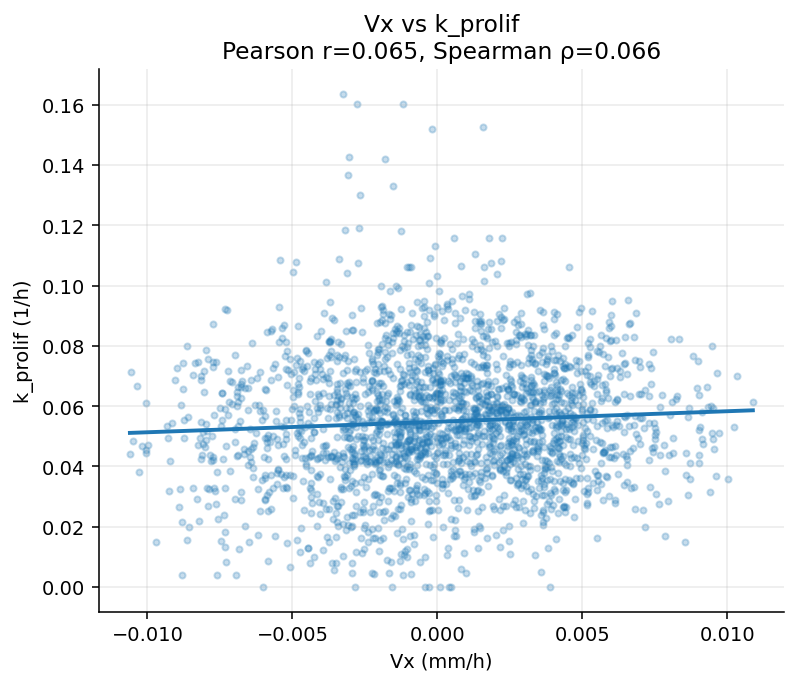

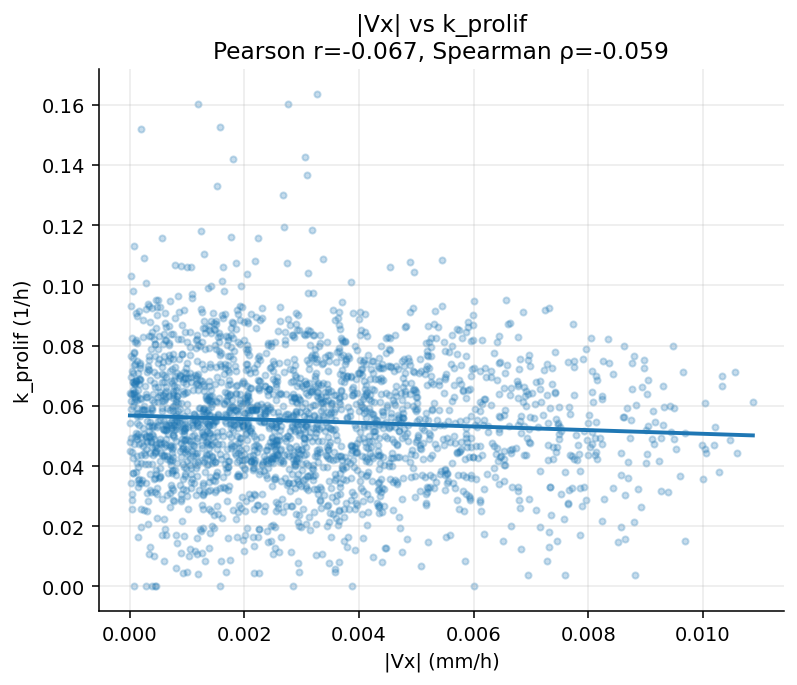


Vx vs k_prolif correlation summary
---------------------------------------------
Valid paired points: 2300
Pearson(Vx, k_prolif)      = 0.0654
Spearman(Vx, k_prolif)     = 0.0660
Pearson(|Vx|, k_prolif)    = -0.0673
Spearman(|Vx|, k_prolif)   = -0.0588

Interpretation:
  Positive correlation  -> higher-velocity regions tend to have higher proliferation.
  Negative correlation  -> higher-velocity regions tend to have lower proliferation.
  Near zero             -> weak or no simple relationship.

[SAVED] outputs in: C:\Users\owner\NADA Project\w400\s161_1\Raw\mass_balance_equation\vx_kprolif_correlation


,analysis,pearson_r,pearson_p,spearman_r,spearman_p,n_valid
0,vx_vs_kprolif,0.065391,0.001703,0.066035,0.001531,2300
1,abs_vx_vs_kprolif,-0.067265,0.001247,-0.058791,0.004796,2300


In [16]:
# ============================================================
# Quick Vx vs k_prolif correlation check
# This is a compact first-pass analysis:
# 1) match Vx and k_prolif on the existing grid
# 2) compute Pearson / Spearman correlations
# 3) make two scatter plots
# ============================================================

from pathlib import Path

try:
    from scipy.stats import pearsonr, spearmanr
    use_scipy_stats = True
except Exception:
    use_scipy_stats = False

# ---- use existing notebook variables ----
if "vx_use" not in globals() or "kprolif_use" not in globals():
    raise RuntimeError("vx_use and kprolif_use must already exist. Run the mass-balance cells first.")

if "x_centers_mm_centered" in globals():
    x_vals = np.asarray(x_centers_mm_centered, dtype=float)
    x_name = "x_center_mm"
    vx_unit = "mm/h"
elif "x_centers_um_centered" in globals():
    x_vals = np.asarray(x_centers_um_centered, dtype=float)
    x_name = "x_center_um"
    vx_unit = "µm/h"
else:
    raise RuntimeError("Could not find x_centers_mm_centered or x_centers_um_centered.")

out_dir = BASE_DIR / "mass_balance_equation" / "vx_kprolif_correlation"
out_dir.mkdir(parents=True, exist_ok=True)

vx_arr = np.asarray(vx_use, dtype=float)
k_arr = np.asarray(kprolif_use, dtype=float)

if vx_arr.shape != k_arr.shape:
    raise RuntimeError(f"Shape mismatch: vx_use {vx_arr.shape} vs kprolif_use {k_arr.shape}")

n_t, n_x = vx_arr.shape

# ---- flatten into matched values ----
df_corr = pd.DataFrame({
    "frame0": np.repeat(pair0s, n_x),
    "t_mid_h": np.repeat(pair_times_h, n_x),
    x_name: np.tile(x_vals, n_t),
    "vx": vx_arr.reshape(-1),
    "abs_vx": np.abs(vx_arr.reshape(-1)),
    "k_prolif": k_arr.reshape(-1),
})

# remove invalid points (e.g. where k_prolif is NaN or infinite) before correlation and plotting
df_corr = df_corr.replace([np.inf, -np.inf], np.nan).dropna(subset=["vx", "abs_vx", "k_prolif"]).reset_index(drop=True)

# optional region label
if x_name == "x_center_mm":
    df_corr["region"] = np.where(np.abs(df_corr[x_name]) < 0.050, "center",
                          np.where(np.abs(df_corr[x_name]) > 0.100, "edge", "intermediate"))
else:
    df_corr["region"] = np.where(np.abs(df_corr[x_name]) < 50, "center",
                          np.where(np.abs(df_corr[x_name]) > 100, "edge", "intermediate"))

# ---- correlation helper ----  # computes correlation and p-value, handling NaNs and small sample sizes 
def get_corr(x, y, method="pearson"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan
    if use_scipy_stats:
        if method == "pearson":
            return pearsonr(x, y)
        else:
            return spearmanr(x, y)
    else:
        if method == "pearson":
            return float(np.corrcoef(x, y)[0, 1]), np.nan
        else:
            xr = pd.Series(x).rank().values
            yr = pd.Series(y).rank().values
            return float(np.corrcoef(xr, yr)[0, 1]), np.nan

# ---- global correlations ----
pearson_vx, p_pearson_vx = get_corr(df_corr["vx"], df_corr["k_prolif"], "pearson")
spearman_vx, p_spearman_vx = get_corr(df_corr["vx"], df_corr["k_prolif"], "spearman")

pearson_abs, p_pearson_abs = get_corr(df_corr["abs_vx"], df_corr["k_prolif"], "pearson")
spearman_abs, p_spearman_abs = get_corr(df_corr["abs_vx"], df_corr["k_prolif"], "spearman")

summary = pd.DataFrame([
    {
        "analysis": "vx_vs_kprolif",
        "pearson_r": pearson_vx,
        "pearson_p": p_pearson_vx,
        "spearman_r": spearman_vx,
        "spearman_p": p_spearman_vx,
        "n_valid": len(df_corr),
    },
    {
        "analysis": "abs_vx_vs_kprolif",
        "pearson_r": pearson_abs,
        "pearson_p": p_pearson_abs,
        "spearman_r": spearman_abs,
        "spearman_p": p_spearman_abs,
        "n_valid": len(df_corr),
    },
])

# ---- save data ----
df_corr.to_csv(out_dir / "vx_kprolif_matched_values.csv", index=False)
summary.to_csv(out_dir / "vx_kprolif_global_summary.csv", index=False)

# ---- scatter 1: vx vs k_prolif ----
fig, ax = plt.subplots(figsize=(5.8, 5.0))
ax.scatter(df_corr["vx"], df_corr["k_prolif"], s=10, alpha=0.25)

if df_corr["vx"].std() > 0:
    m, b = np.polyfit(df_corr["vx"], df_corr["k_prolif"], 1)
    xx = np.linspace(df_corr["vx"].min(), df_corr["vx"].max(), 200)
    ax.plot(xx, m * xx + b, lw=2)

ax.set_xlabel(f"Vx ({vx_unit})")
ax.set_ylabel("k_prolif (1/h)")
ax.set_title(f"Vx vs k_prolif\nPearson r={pearson_vx:.3f}, Spearman ρ={spearman_vx:.3f}")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(out_dir / "vx_vs_kprolif_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- scatter 2: |vx| vs k_prolif ----
fig, ax = plt.subplots(figsize=(5.8, 5.0))
ax.scatter(df_corr["abs_vx"], df_corr["k_prolif"], s=10, alpha=0.25)

if df_corr["abs_vx"].std() > 0:
    m, b = np.polyfit(df_corr["abs_vx"], df_corr["k_prolif"], 1)
    xx = np.linspace(df_corr["abs_vx"].min(), df_corr["abs_vx"].max(), 200)
    ax.plot(xx, m * xx + b, lw=2)

ax.set_xlabel(f"|Vx| ({vx_unit})")
ax.set_ylabel("k_prolif (1/h)")
ax.set_title(f"|Vx| vs k_prolif\nPearson r={pearson_abs:.3f}, Spearman ρ={spearman_abs:.3f}")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(out_dir / "abs_vx_vs_kprolif_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- short interpretation ----
print("\nVx vs k_prolif correlation summary")
print("-" * 45)
print(f"Valid paired points: {len(df_corr)}")
print(f"Pearson(Vx, k_prolif)      = {pearson_vx:.4f}")
print(f"Spearman(Vx, k_prolif)     = {spearman_vx:.4f}")
print(f"Pearson(|Vx|, k_prolif)    = {pearson_abs:.4f}")
print(f"Spearman(|Vx|, k_prolif)   = {spearman_abs:.4f}")
print("")
print("Interpretation:")
print("  Positive correlation  -> higher-velocity regions tend to have higher proliferation.")
print("  Negative correlation  -> higher-velocity regions tend to have lower proliferation.")
print("  Near zero             -> weak or no simple relationship.")
print("")
print("Warning: correlation does not prove causation.")
print("[SAVED] outputs in:", out_dir)
display(summary)

### Local correlation: source/divergence vs k_prolif

#### Prepare local matched source/divergence and k_prolif values

In [17]:
# Prepare local matched source/divergence and k_prolif values

required = [
    "BASE_DIR", "pair0s", "pair_times_h", "x_centers_mm_centered",
    "kprolif_use", "dflux_dx_xt", "lhs_xt", "residual_xt"
]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Run the earlier mass-balance cells first. Missing: {missing}")

# Choose what to compare with k_prolif.
# dflux_dx_xt = local flux divergence, good for compression/expansion.
# lhs_xt = net source needed by the mass balance.
# residual_xt = imbalance after subtracting proliferation, but use carefully because it already contains k_prolif.
TERM_TO_TEST = "dflux_dx_xt"

term_options = {
    "dflux_dx_xt": (dflux_dx_xt, "flux divergence d/dx(rho vx)", "cells/(mm^2 h)"),
    "lhs_xt": (lhs_xt, "net source from LHS", "cells/(mm^2 h)"),
    "residual_xt": (residual_xt, "residual imbalance", "cells/(mm^2 h)"),
}

source_arr, source_title, source_unit = term_options[TERM_TO_TEST]
source_arr = np.asarray(source_arr, dtype=float)
k_arr = np.asarray(kprolif_use, dtype=float)

if source_arr.shape != k_arr.shape:
    raise RuntimeError(f"Shape mismatch: {source_arr.shape} vs {k_arr.shape}")

n_t, n_x = source_arr.shape

corr_dir = BASE_DIR / "mass_balance_equation" / "source_kprolif_local_correlation"
corr_dir.mkdir(parents=True, exist_ok=True)

df_local_pairs = pd.DataFrame({
    "frame0": np.repeat(pair0s, n_x),
    "t_mid_h": np.repeat(pair_times_h, n_x),
    "x_center_mm": np.tile(x_centers_mm_centered, n_t),
    "term_used": TERM_TO_TEST,
    "source_or_divergence": source_arr.reshape(-1),
    "abs_source_or_divergence": np.abs(source_arr.reshape(-1)),
    "k_prolif_per_h": k_arr.reshape(-1),
})

# Remove bad values before doing statistics
df_local_pairs = (
    df_local_pairs
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["source_or_divergence", "abs_source_or_divergence", "k_prolif_per_h"])
    .reset_index(drop=True)
)

pairs_csv = corr_dir / f"{TERM_TO_TEST}_kprolif_local_pairs.csv"
df_local_pairs.to_csv(pairs_csv, index=False)

print("This is local x,t analysis. The current notebook does not have y-resolved mass-balance fields.")
print("[SAVED]", pairs_csv)
display(df_local_pairs.head())

This is local x,t analysis. The current notebook does not have y-resolved mass-balance fields.
[SAVED] C:\Users\owner\NADA Project\w400\s161_1\Raw\mass_balance_equation\source_kprolif_local_correlation\dflux_dx_xt_kprolif_local_pairs.csv


,frame0,t_mid_h,x_center_mm,term_used,source_or_divergence,abs_source_or_divergence,k_prolif_per_h
0,0,0.125,-0.19573,dflux_dx_xt,-80.617732,80.617732,0.048309
1,0,0.125,-0.17723,dflux_dx_xt,-67.971607,67.971607,0.088409
2,0,0.125,-0.15873,dflux_dx_xt,-46.575353,46.575353,0.130076
3,0,0.125,-0.14023,dflux_dx_xt,-37.714059,37.714059,0.108840
4,0,0.125,-0.12173,dflux_dx_xt,-46.813538,46.813538,0.068739


#### Calculate local correlations

In [18]:
# Calculate local correlations

try:
    from scipy.stats import pearsonr, spearmanr
    have_scipy_stats = True
except Exception:
    have_scipy_stats = False

def simple_corr(x, y, method):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]

    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    if have_scipy_stats:
        if method == "pearson":
            r, p = pearsonr(x, y)
        else:
            r, p = spearmanr(x, y)
        return float(r), float(p)

    if method == "pearson":
        return float(np.corrcoef(x, y)[0, 1]), np.nan

    # Spearman is Pearson on ranks
    xr = pd.Series(x).rank().values
    yr = pd.Series(y).rank().values
    return float(np.corrcoef(xr, yr)[0, 1]), np.nan

# Pearson checks linear correlation.
# Spearman checks monotonic/rank correlation.
# The absolute value checks strength of local compression/expansion, ignoring sign.
pearson_source, p_pearson_source = simple_corr(df_local_pairs["source_or_divergence"], df_local_pairs["k_prolif_per_h"], "pearson")
spearman_source, p_spearman_source = simple_corr(df_local_pairs["source_or_divergence"], df_local_pairs["k_prolif_per_h"], "spearman")
pearson_abs, p_pearson_abs = simple_corr(df_local_pairs["abs_source_or_divergence"], df_local_pairs["k_prolif_per_h"], "pearson")
spearman_abs, p_spearman_abs = simple_corr(df_local_pairs["abs_source_or_divergence"], df_local_pairs["k_prolif_per_h"], "spearman")

df_corr_summary = pd.DataFrame([
    ["source_or_divergence vs k_prolif", "pearson", pearson_source, p_pearson_source, len(df_local_pairs)],
    ["source_or_divergence vs k_prolif", "spearman", spearman_source, p_spearman_source, len(df_local_pairs)],
    ["abs_source_or_divergence vs k_prolif", "pearson", pearson_abs, p_pearson_abs, len(df_local_pairs)],
    ["abs_source_or_divergence vs k_prolif", "spearman", spearman_abs, p_spearman_abs, len(df_local_pairs)],
], columns=["comparison", "method", "correlation", "p_value", "n_valid"])

summary_csv = corr_dir / f"{TERM_TO_TEST}_kprolif_correlation_summary.csv"
df_corr_summary.to_csv(summary_csv, index=False)

print("[SAVED]", summary_csv)
display(df_corr_summary)

[SAVED] C:\Users\owner\NADA Project\w400\s161_1\Raw\mass_balance_equation\source_kprolif_local_correlation\dflux_dx_xt_kprolif_correlation_summary.csv


,comparison,method,correlation,p_value,n_valid
0,source_or_divergence vs k_prolif,pearson,-0.038810,0.062748,2300
1,source_or_divergence vs k_prolif,spearman,-0.026429,0.205151,2300
2,abs_source_or_divergence vs k_prolif,pearson,-0.045873,0.027810,2300
3,abs_source_or_divergence vs k_prolif,spearman,-0.031718,0.128331,2300


#### Plot local source/divergence vs k_prolif

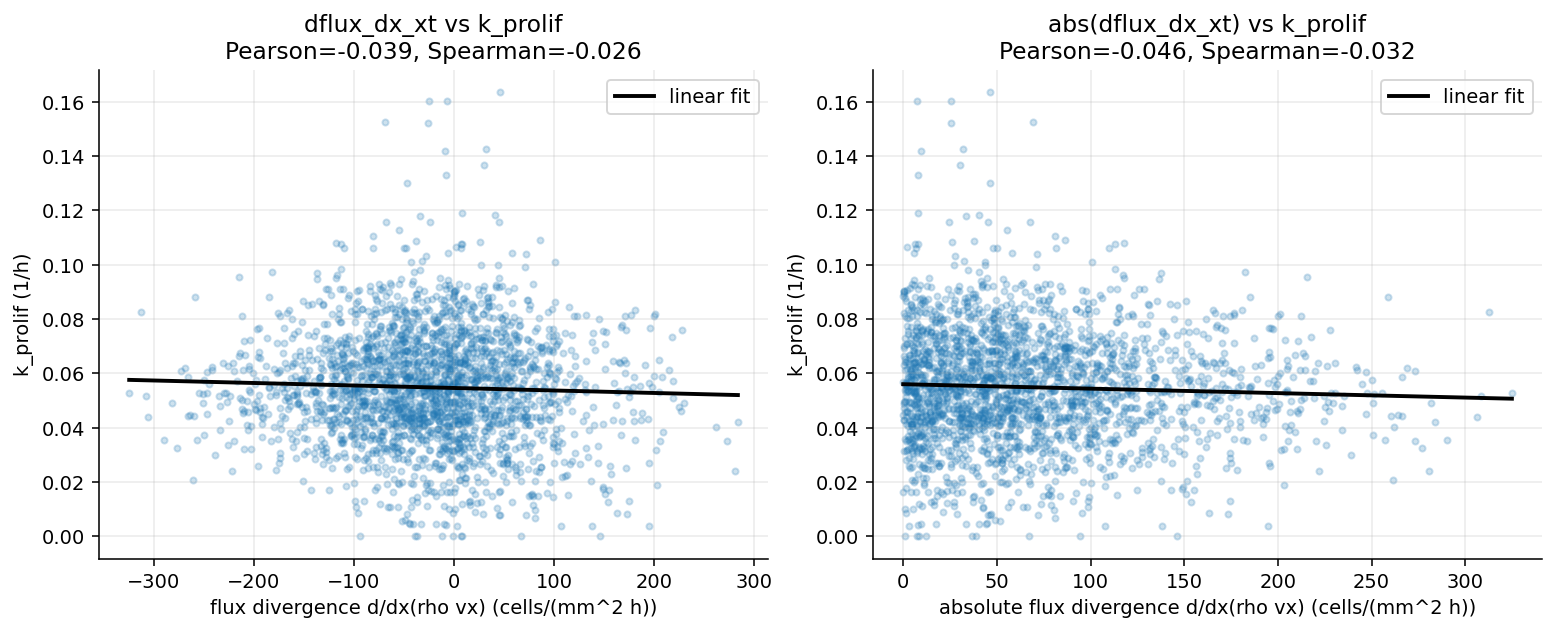

[SAVED] C:\Users\owner\NADA Project\w400\s161_1\Raw\mass_balance_equation\source_kprolif_local_correlation\dflux_dx_xt_kprolif_scatter_plots.png


In [21]:
# Plot local source/divergence vs k_prolif

fig, axs = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)

axs[0].scatter(df_local_pairs["source_or_divergence"], df_local_pairs["k_prolif_per_h"], s=10, alpha=0.22)
# simple linear fit line
x_fit = df_local_pairs["source_or_divergence"].values
y_fit = df_local_pairs["k_prolif_per_h"].values
ok = np.isfinite(x_fit) & np.isfinite(y_fit)

if ok.sum() > 2 and np.std(x_fit[ok]) > 0:
    m, b = np.polyfit(x_fit[ok], y_fit[ok], 1)
    xx = np.linspace(x_fit[ok].min(), x_fit[ok].max(), 200)
    axs[0].plot(xx, m * xx + b, color="black", lw=2, label="linear fit")
    axs[0].legend()

axs[0].set_xlabel(f"{source_title} ({source_unit})")
axs[0].set_ylabel("k_prolif (1/h)")
axs[0].set_title(f"{TERM_TO_TEST} vs k_prolif\nPearson={pearson_source:.3f}, Spearman={spearman_source:.3f}")
axs[0].grid(alpha=0.25)

axs[1].scatter(df_local_pairs["abs_source_or_divergence"], df_local_pairs["k_prolif_per_h"], s=10, alpha=0.22)
# simple linear fit line
x_fit = df_local_pairs["abs_source_or_divergence"].values
y_fit = df_local_pairs["k_prolif_per_h"].values
ok = np.isfinite(x_fit) & np.isfinite(y_fit)

if ok.sum() > 2 and np.std(x_fit[ok]) > 0:
    m, b = np.polyfit(x_fit[ok], y_fit[ok], 1)
    xx = np.linspace(x_fit[ok].min(), x_fit[ok].max(), 200)
    axs[1].plot(xx, m * xx + b, color="black", lw=2, label="linear fit")
    axs[1].legend()
    
axs[1].set_xlabel(f"absolute {source_title} ({source_unit})")
axs[1].set_ylabel("k_prolif (1/h)")
axs[1].set_title(f"abs({TERM_TO_TEST}) vs k_prolif\nPearson={pearson_abs:.3f}, Spearman={spearman_abs:.3f}")
axs[1].grid(alpha=0.25)

scatter_png = corr_dir / f"{TERM_TO_TEST}_kprolif_scatter_plots.png"
fig.savefig(scatter_png, dpi=300, bbox_inches="tight")
plt.show()

print("[SAVED]", scatter_png)

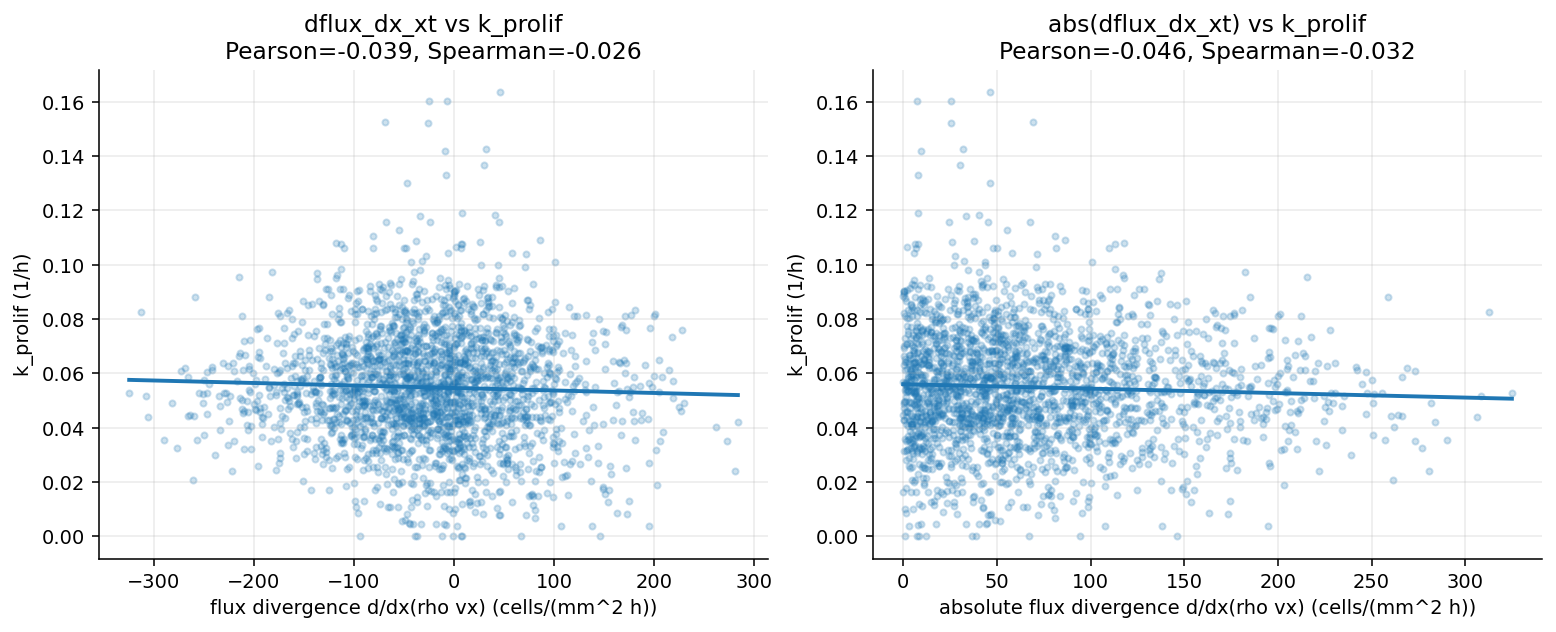

[SAVED] C:\Users\owner\NADA Project\w400\s161_1\Raw\mass_balance_equation\source_kprolif_local_correlation\dflux_dx_xt_kprolif_scatter_plots.png


In [22]:
# Plot local source/divergence vs k_prolif

fig, axs = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)

axs[0].scatter(df_local_pairs["source_or_divergence"], df_local_pairs["k_prolif_per_h"], s=10, alpha=0.22)

m, b = np.polyfit(df_local_pairs["source_or_divergence"], df_local_pairs["k_prolif_per_h"], 1)
axs[0].plot(np.sort(df_local_pairs["source_or_divergence"]), m*np.sort(df_local_pairs["source_or_divergence"]) + b, linewidth=2)

axs[0].set_xlabel(f"{source_title} ({source_unit})")
axs[0].set_ylabel("k_prolif (1/h)")
axs[0].set_title(f"{TERM_TO_TEST} vs k_prolif\nPearson={pearson_source:.3f}, Spearman={spearman_source:.3f}")
axs[0].grid(alpha=0.25)

axs[1].scatter(df_local_pairs["abs_source_or_divergence"], df_local_pairs["k_prolif_per_h"], s=10, alpha=0.22)

m, b = np.polyfit(df_local_pairs["abs_source_or_divergence"], df_local_pairs["k_prolif_per_h"], 1)
axs[1].plot(np.sort(df_local_pairs["abs_source_or_divergence"]), m*np.sort(df_local_pairs["abs_source_or_divergence"]) + b, linewidth=2)

axs[1].set_xlabel(f"absolute {source_title} ({source_unit})")
axs[1].set_ylabel("k_prolif (1/h)")
axs[1].set_title(f"abs({TERM_TO_TEST}) vs k_prolif\nPearson={pearson_abs:.3f}, Spearman={spearman_abs:.3f}")
axs[1].grid(alpha=0.25)

scatter_png = corr_dir / f"{TERM_TO_TEST}_kprolif_scatter_plots.png"
fig.savefig(scatter_png, dpi=300, bbox_inches="tight")
plt.show()

print("[SAVED]", scatter_png)

#### Binned trend plot

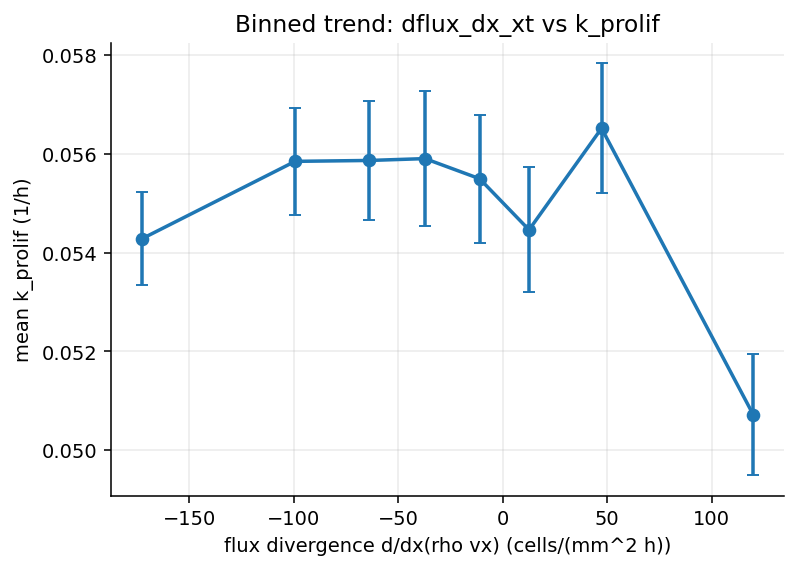

[SAVED] C:\Users\owner\NADA Project\w400\s161_1\Raw\mass_balance_equation\source_kprolif_local_correlation\dflux_dx_xt_kprolif_binned_trend.csv
[SAVED] C:\Users\owner\NADA Project\w400\s161_1\Raw\mass_balance_equation\source_kprolif_local_correlation\dflux_dx_xt_kprolif_binned_trend.png


,source_bin,source_bin_center,mean_k_prolif,std_k_prolif,n,sem_k_prolif
0,"(-324.87, -121.871]",-172.695521,0.054277,0.016000,288,0.000943
1,"(-121.871, -80.44]",-99.323723,0.055846,0.018444,287,0.001089
2,"(-80.44, -49.988]",-63.836337,0.055864,0.020570,288,0.001212
3,"(-49.988, -23.707]",-37.196884,0.055902,0.023188,287,0.001369
4,"(-23.707, 0.395]",-11.064188,0.055494,0.021892,287,0.001292
5,"(0.395, 28.471]",12.556350,0.054460,0.021431,288,0.001263
6,"(28.471, 69.455]",47.239359,0.056515,0.022255,287,0.001314
7,"(69.455, 283.815]",119.804093,0.050718,0.020720,288,0.001221


In [ ]:
# Binned trend plot

N_BINS = 8

if df_local_pairs["source_or_divergence"].nunique() < 3:
    print("Not enough different source/divergence values for a binned trend plot.")
else:
    df_bin = df_local_pairs.copy()
    df_bin["source_bin"] = pd.qcut(df_bin["source_or_divergence"], q=N_BINS, duplicates="drop")

    df_binned = (
        df_bin.groupby("source_bin", observed=True)
        .agg(
            source_bin_center=("source_or_divergence", "mean"),
            mean_k_prolif=("k_prolif_per_h", "mean"),
            std_k_prolif=("k_prolif_per_h", "std"),
            n=("k_prolif_per_h", "size"),
        )
        .reset_index()
    )
    df_binned["sem_k_prolif"] = (df_binned["std_k_prolif"] / np.sqrt(df_binned["n"])).fillna(0)

    binned_csv = corr_dir / f"{TERM_TO_TEST}_kprolif_binned_trend.csv"
    df_binned.to_csv(binned_csv, index=False)

    fig, ax = plt.subplots(figsize=(6.2, 4.2))
    ax.errorbar(
        df_binned["source_bin_center"],
        df_binned["mean_k_prolif"],
        yerr=df_binned["sem_k_prolif"],
        marker="o",
        capsize=3,
        lw=1.8,
    )
    ax.set_xlabel(f"{source_title} ({source_unit})")
    ax.set_ylabel("mean k_prolif (1/h)")
    ax.set_title(f"Binned trend: {TERM_TO_TEST} vs k_prolif")
    ax.grid(alpha=0.25)

    binned_png = corr_dir / f"{TERM_TO_TEST}_kprolif_binned_trend.png"
    fig.savefig(binned_png, dpi=300, bbox_inches="tight")
    plt.show()

    print("[SAVED]", binned_csv)
    print("[SAVED]", binned_png)
    display(df_binned)